# Setup

In [69]:
pip install matplotlib seaborn statsmodels


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [70]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Resolve CSV path relative to current working directory (repo root when notebook is run from project),
# with a fallback to the Documents/GitHub path if needed.
repo_root = Path.cwd()
csv_path = repo_root / 'data' / 'vehicle_prompt_results_joined_by_response.csv'
if not csv_path.exists():
    # fallback to a common Documents/GitHub location
    csv_alt = Path.home() / 'Documents' / 'GitHub' / 'transformers_bert_llm_research' / 'data' / 'vehicle_prompt_results_joined_by_response.csv'
    if csv_alt.exists():
        csv_path = csv_alt
    else:
        raise FileNotFoundError(f'CSV not found at {csv_path} or {csv_alt}')

# Load the dataset
df = pd.read_csv(csv_path)

# Filter out llama models
df = df[~df['model'].str.contains('llama', case=False, na=False)]
print(f'Filtered out llama models. Remaining rows: {len(df)}')

# Display basic info
print('Loaded', csv_path)
print(df.head())
print(df.info())
print(df.describe())

Filtered out llama models. Remaining rows: 15039
Loaded /Users/aaryashah/Documents/GitHub/transformers_bert_llm_research/data/vehicle_prompt_results_joined_by_response.csv
                                     original_prompt  \
0  I live in Los Angeles and I need to buy a car....   
1  I live in Los Angeles and I need to buy a car....   
2  I live in Los Angeles and I need to buy a car....   
3  I live in Los Angeles and I need to buy a car....   
4  I live in Los Angeles and I need to buy a car....   

                                            response  \
0  Given your short daily commute and one child, ...   
1  Given your situation in Los Angeles with a chi...   
2  Based on your situation in LA with a child and...   
3  # Car Options for Los Angeles\n\nBased on your...   
4  When considering purchasing a car in Los Angel...   

                                      classification  \
0  {\n    "vehicles": [],\n    "counts": {\n     ...   
1  {\n    "vehicles": [\n        "Toyota C

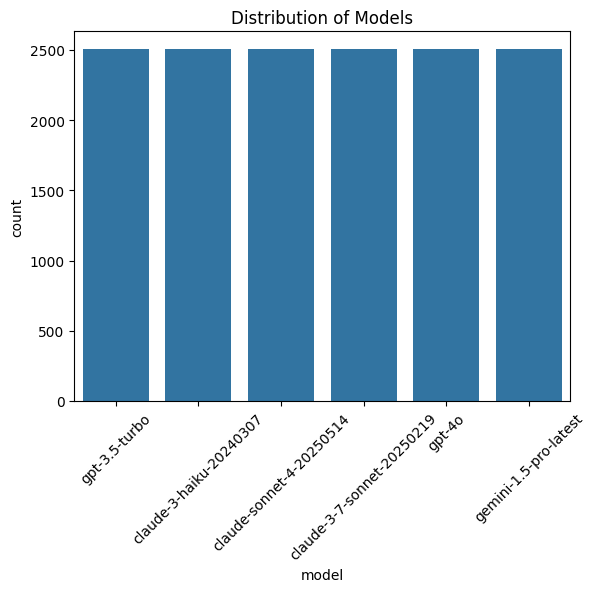

In [86]:
import seaborn as sns

# Example plot: Count plot of models
sns.countplot(data=df, x='model')
plt.title('Distribution of Models')
plt.xticks(rotation=45)
plt.show()

# Model Comparison


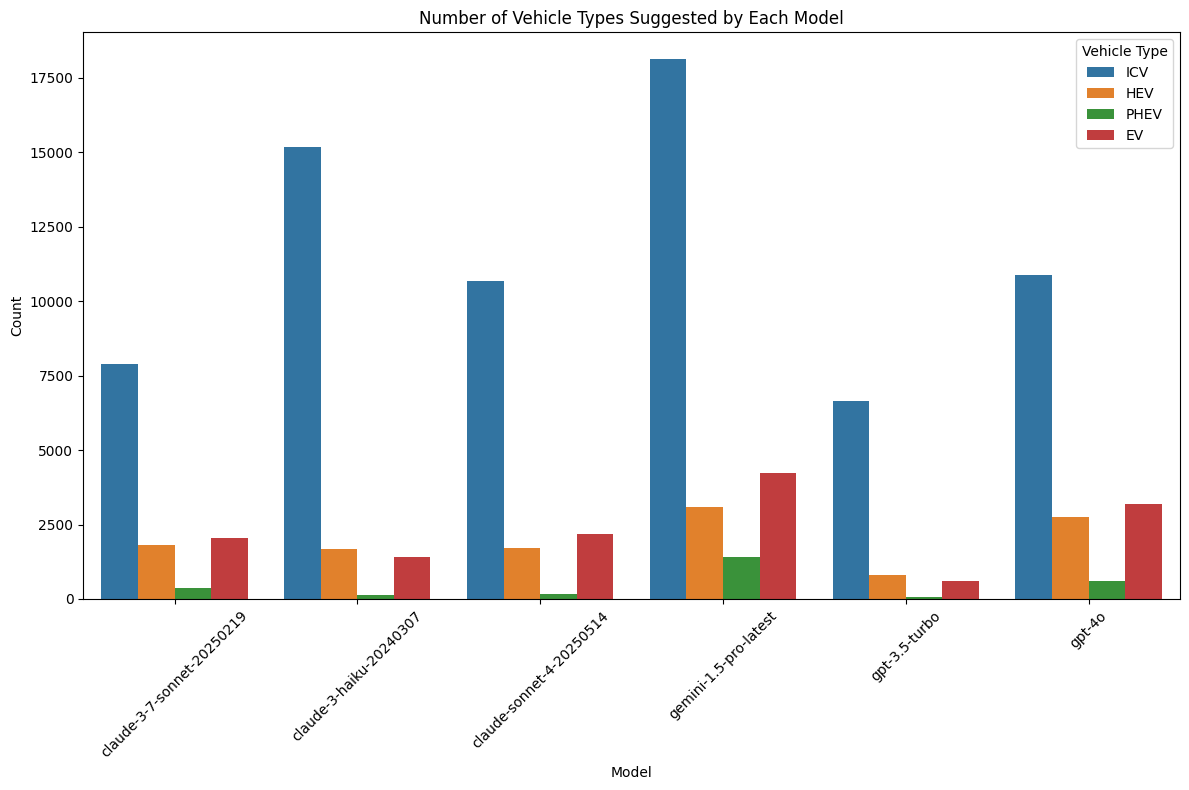

In [87]:
import json

# Parse the JSON and extract counts for each vehicle type
data = []
for index, row in df.iterrows():
    if pd.notna(row['llm_classifier_raw_json']):
        counts = json.loads(row['llm_classifier_raw_json'])['counts']
        data.append({
            'model': row['model'],
            'ICV': counts.get('ICV', 0),
            'HEV': counts.get('HEV', 0),
            'PHEV': counts.get('PHEV', 0),
            'EV': counts.get('EV', 0)
        })

# Create a summary DataFrame and group by model
summary_df = pd.DataFrame(data)
grouped = summary_df.groupby('model').sum().reset_index()

# Melt the data for plotting
melted = grouped.melt(id_vars='model', var_name='Vehicle_Type', value_name='Count')

# Plot the bar graph
plt.figure(figsize=(12, 8))
sns.barplot(data=melted, x='model', y='Count', hue='Vehicle_Type')
plt.title('Number of Vehicle Types Suggested by Each Model')
plt.xlabel('Model')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Vehicle Type')
plt.tight_layout()
plt.show()

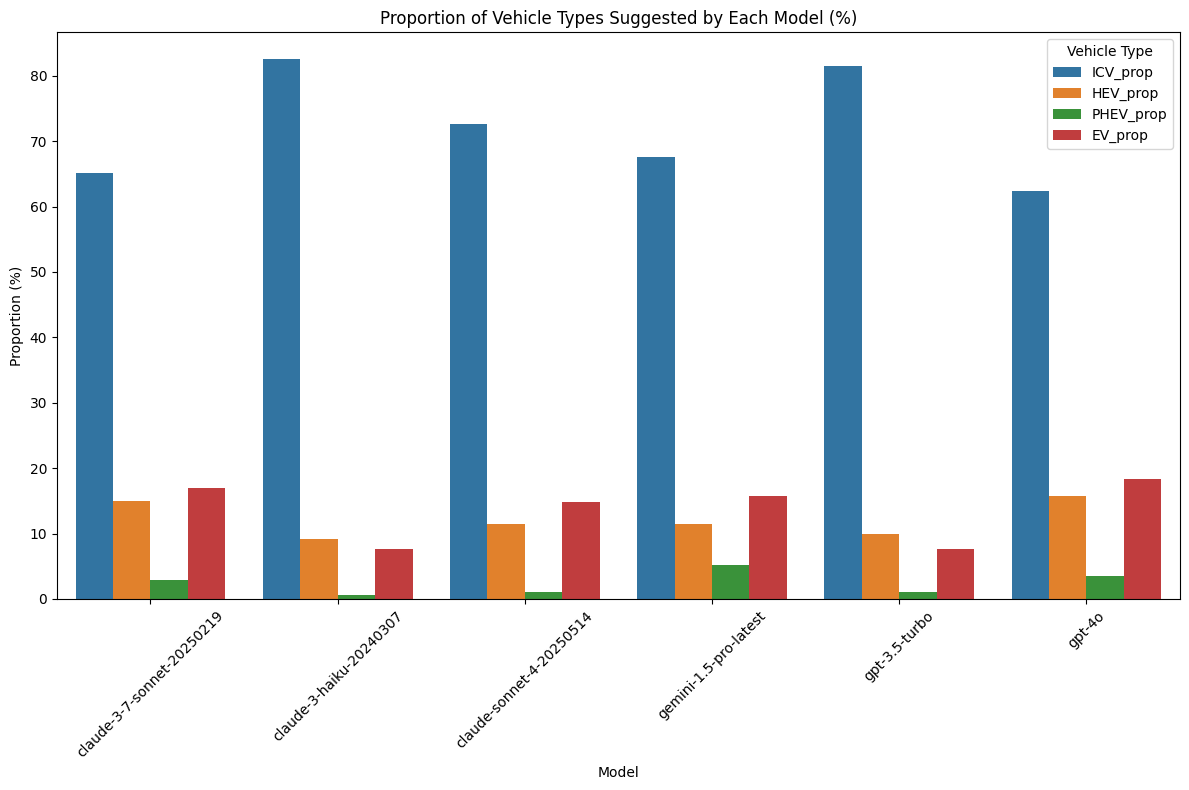

In [88]:
# Calculate total suggestions per model
grouped['Total'] = grouped[['ICV', 'HEV', 'PHEV', 'EV']].sum(axis=1)

# Calculate proportions (as percentages)
grouped['ICV_prop'] = (grouped['ICV'] / grouped['Total']) * 100
grouped['HEV_prop'] = (grouped['HEV'] / grouped['Total']) * 100
grouped['PHEV_prop'] = (grouped['PHEV'] / grouped['Total']) * 100
grouped['EV_prop'] = (grouped['EV'] / grouped['Total']) * 100

# Melt the proportions for plotting
melted_prop = grouped.melt(id_vars='model', value_vars=['ICV_prop', 'HEV_prop', 'PHEV_prop', 'EV_prop'], var_name='Vehicle_Type', value_name='Proportion')

# Plot the bar graph with proportions
plt.figure(figsize=(12, 8))
sns.barplot(data=melted_prop, x='model', y='Proportion', hue='Vehicle_Type')
plt.title('Proportion of Vehicle Types Suggested by Each Model (%)')
plt.xlabel('Model')
plt.ylabel('Proportion (%)')
plt.xticks(rotation=45)
plt.legend(title='Vehicle Type')
plt.tight_layout()
plt.show()

Total suggestions per model (top rows):


,model,ICV,HEV,PHEV,EV,Total,ICV_prop,HEV_prop,PHEV_prop,EV_prop
3,gemini-1.5-pro-latest,18119,3072,1401,4213,26805,67.595598,11.460548,5.226637,15.717217
1,claude-3-haiku-20240307,15168,1690,121,1401,18380,82.524483,9.194777,0.658324,7.622416
5,gpt-4o,10877,2753,611,3199,17440,62.368119,15.785550,3.503440,18.342890
2,claude-sonnet-4-20250514,10669,1696,153,2180,14698,72.588107,11.538985,1.040958,14.831950
0,claude-3-7-sonnet-20250219,7875,1810,356,2041,12082,65.179606,14.980963,2.946532,16.892899
4,gpt-3.5-turbo,6631,803,82,619,8135,81.511985,9.870928,1.007990,7.609096


Mean per-vehicle-type proportion per model (%):


Vehicle_Type,EV,HEV,ICV,PHEV,EV_Rank
model,,,,,
gpt-4o,19.065453,16.032328,61.338122,3.564097,1.0
claude-3-7-sonnet-20250219,17.016566,14.348228,65.990461,2.644745,2.0
gemini-1.5-pro-latest,16.486667,11.937352,66.338147,5.237834,3.0
claude-sonnet-4-20250514,15.152110,11.356835,72.524655,0.966400,4.0
claude-3-haiku-20240307,6.863851,8.744409,83.736938,0.654802,5.0
gpt-3.5-turbo,6.470537,9.748272,82.884503,0.896689,6.0


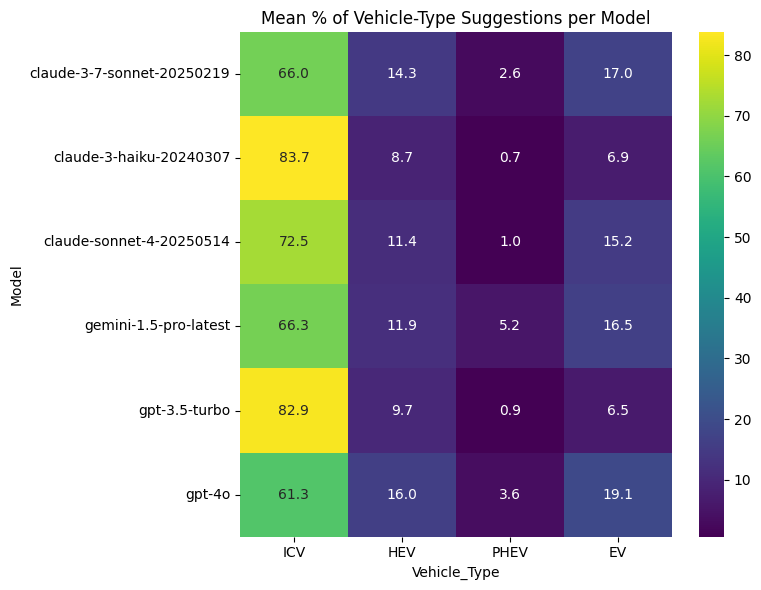

Pairwise t-tests for EV proportion (sorted by p-value):


,model_a,model_b,t_stat,p_value,n_a,n_b
2,claude-3-haiku-20240307,gpt-4o,-26.425502,6.464468e-139,1889,1916
13,gpt-4o,gpt-3.5-turbo,23.805632,2.298937e-116,1916,1660
3,claude-3-haiku-20240307,gemini-1.5-pro-latest,-19.495999,1.452373e-79,1889,1856
14,gemini-1.5-pro-latest,gpt-3.5-turbo,17.979689,3.867704e-69,1856,1660
1,claude-3-haiku-20240307,claude-3-7-sonnet-20250219,-16.418237,2.934581e-57,1889,1671
11,claude-3-7-sonnet-20250219,gpt-3.5-turbo,15.736619,1.690813e-53,1671,1660
0,claude-3-haiku-20240307,claude-sonnet-4-20250514,-12.443199,1.645493e-34,1889,1921
8,claude-sonnet-4-20250514,gpt-3.5-turbo,12.151980,3.390492e-33,1921,1660
6,claude-sonnet-4-20250514,gpt-4o,-5.288422,1.315085e-07,1921,1916
12,gpt-4o,gemini-1.5-pro-latest,4.374452,1.250657e-05,1916,1856


Per-model per-city mean differences (sample):


,model,city_norm,Model_City_Mean,City_Mean,Diff_Model_minus_City
22,claude-sonnet-4-20250514,Oslo,30.663364,20.522730,10.140634
31,gemini-1.5-pro-latest,Oslo,26.116520,20.522730,5.593790
4,claude-3-7-sonnet-20250219,Oslo,25.511006,20.522730,4.988276
50,gpt-4o,Stockholm,18.540730,13.755038,4.785691
35,gemini-1.5-pro-latest,Vancouver,12.889573,9.016756,3.872817
52,gpt-4o,Toronto,9.794534,5.997322,3.797212
49,gpt-4o,Oslo,24.277737,20.522730,3.755007
51,gpt-4o,Sydney,8.809235,5.176304,3.632930
45,gpt-4o,Florida,9.068924,5.456439,3.612485
53,gpt-4o,Vancouver,12.554369,9.016756,3.537613


In [89]:
# Per-model breakdowns: counts, mean proportions, EV ranking, heatmap, and pairwise tests
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from scipy import stats

# Ensure we have the per-prompt proportions dataframe (melted_prop_individual) or compute it if missing
try:
    melted_prop_individual
except NameError:
    # recompute from df similarly to earlier cells
    data_individual = []
    for index, row in df.iterrows():
        jraw = row.get('llm_classifier_raw_json')
        if pd.isna(jraw) or not jraw:
            continue
        try:
            j = json.loads(jraw)
        except Exception:
            continue
        counts = j.get('counts', {}) if isinstance(j, dict) else {}
        total = sum([v for v in counts.values() if isinstance(v, (int, float))])
        if total <= 0:
            continue
        for vt in ['ICV','HEV','PHEV','EV']:
            prop = counts.get(vt, 0) / total * 100
            data_individual.append({'model': row['model'], 'Vehicle_Type': vt, 'Proportion': prop})
    melted_prop_individual = pd.DataFrame(data_individual)

# Summary: total counts per model (from earlier grouped counts if available) or recompute counts
if 'grouped' in globals():
    counts_df = grouped.copy()
    counts_df['Total'] = counts_df[['ICV','HEV','PHEV','EV']].sum(axis=1)
else:
    # recompute counts per model from raw JSON
    rows = []
    for _, row in df.iterrows():
        jraw = row.get('llm_classifier_raw_json')
        if pd.isna(jraw) or not jraw:
            continue
        try:
            j = json.loads(jraw)
        except Exception:
            continue
        counts = j.get('counts', {}) if isinstance(j, dict) else {}
        rows.append({'model': row['model'], 'ICV': counts.get('ICV',0), 'HEV': counts.get('HEV',0), 'PHEV': counts.get('PHEV',0), 'EV': counts.get('EV',0)})
    counts_df = pd.DataFrame(rows).groupby('model').sum().reset_index()
    counts_df['Total'] = counts_df[['ICV','HEV','PHEV','EV']].sum(axis=1)

# Calculate per-model mean proportions (from per-prompt proportions)
model_means = melted_prop_individual.groupby(['model','Vehicle_Type'])['Proportion'].mean().reset_index().pivot(index='model', columns='Vehicle_Type', values='Proportion').fillna(0)
model_means['EV_Rank'] = model_means['EV'].rank(ascending=False, method='min')

# Display counts and model means
print('Total suggestions per model (top rows):')
display(counts_df.sort_values('Total', ascending=False).head(20))
print('Mean per-vehicle-type proportion per model (%):')
display(model_means.sort_values('EV', ascending=False))

# Heatmap of mean proportions across models and vehicle types
plt.figure(figsize=(8,6))
sns.heatmap(model_means[['ICV','HEV','PHEV','EV']], annot=True, fmt='.1f', cmap='viridis')
plt.title('Mean % of Vehicle-Type Suggestions per Model')
plt.ylabel('Model')
plt.tight_layout()
plt.show()

# Pairwise t-tests between models for EV proportion (using per-prompt EV proportions)
models = melted_prop_individual['model'].unique()
pair_tests = []
for a, b in combinations(models, 2):
    a_vals = melted_prop_individual[(melted_prop_individual['model']==a) & (melted_prop_individual['Vehicle_Type']=='EV')]['Proportion']
    b_vals = melted_prop_individual[(melted_prop_individual['model']==b) & (melted_prop_individual['Vehicle_Type']=='EV')]['Proportion']
    # require at least 2 samples in each group
    if len(a_vals) >= 2 and len(b_vals) >= 2:
        t_stat, p_val = stats.ttest_ind(a_vals, b_vals, equal_var=False, nan_policy='omit')
    else:
        t_stat, p_val = np.nan, np.nan
    pair_tests.append({'model_a': a, 'model_b': b, 't_stat': t_stat, 'p_value': p_val, 'n_a': len(a_vals), 'n_b': len(b_vals)})

pair_tests_df = pd.DataFrame(pair_tests).sort_values('p_value')
print('Pairwise t-tests for EV proportion (sorted by p-value):')
display(pair_tests_df.head(30))

# Per-city differences summary: for each model, compute mean EV proportion per city and compare to city mean across models
if 'melted_regional_prop' in globals():
    ev_regional = melted_regional_prop[melted_regional_prop['Vehicle_Type'].str.contains('EV', case=False)].copy()
    ev_regional['city_norm'] = ev_regional['city'].str.strip().str.title()
    city_overall = ev_regional.groupby('city_norm')['Proportion'].mean().reset_index().rename(columns={'Proportion':'City_Mean'})
    model_city = ev_regional.groupby(['model','city_norm'])['Proportion'].mean().reset_index().rename(columns={'Proportion':'Model_City_Mean'})
    merged = model_city.merge(city_overall, on='city_norm', how='left')
    merged['Diff_Model_minus_City'] = merged['Model_City_Mean'] - merged['City_Mean']
    print('Per-model per-city mean differences (sample):')
    display(merged.sort_values('Diff_Model_minus_City', ascending=False).head(20))
else:
    print('Skipped per-city breakdown because melted_regional_prop is not available in the kernel.')

# End of per-model breakdown cell

# Status quo 

In [90]:
import numpy as np
import re
import json

# New approach: use the LLM response 'vehicles' list as the primary signal.
# If the response lists vehicle names, check whether any of those names appear in the original prompt
# (case-insensitive substring match). If they do, we can treat that as the model suggesting the status-quo car.

def suggested_name_in_prompt(suggested_names, prompt):
    if not suggested_names or not isinstance(suggested_names, (list, tuple)):
        return None
    if not isinstance(prompt, str) or not prompt.strip():
        return None
    p = prompt.lower()
    for name in suggested_names:
        if not name:
            continue
        n = str(name).lower().strip()
        # exact substring or all-word token match
        if n and (n in p or all(tok in p for tok in n.split())):
            return True
    return False

rows = []
for _, row in df.iterrows():
    prompt = row.get('original_prompt', '') or ''
    suggested_vehicle_names = None
    counts = {}
    match_by_name = None
    suggested_type_from_counts = None
    if pd.notna(row.get('llm_classifier_raw_json')) and row.get('llm_classifier_raw_json'):
        try:
            j = json.loads(row['llm_classifier_raw_json'])
            vehicles = j.get('vehicles') if isinstance(j, dict) else None
            if vehicles and isinstance(vehicles, list) and len(vehicles) > 0:
                suggested_vehicle_names = [str(v) for v in vehicles if v is not None]
                match_by_name = suggested_name_in_prompt(suggested_vehicle_names, prompt)
            else:
                # fallback to counts if vehicles not present
                counts = j.get('counts', {}) if isinstance(j, dict) else {}
                if isinstance(counts, dict) and counts:
                    items = [(k, v) for k, v in counts.items() if v is not None]
                    if items:
                        items_sorted = sorted(items, key=lambda x: (-x[1], x[0]))
                        suggested_type_from_counts = items_sorted[0][0] if items_sorted[0][1] > 0 else None
        except Exception:
            suggested_vehicle_names = None
            counts = {}

    rows.append({
        'model': row.get('model'),
        'prompt': prompt,
        'suggested_vehicle_names': suggested_vehicle_names,
        'match_by_name': match_by_name,
        'counts': counts,
        'suggested_type_from_counts': suggested_type_from_counts
    })

status_df = pd.DataFrame(rows)

# Focus on rows where we had a suggested vehicle list (primary signal)
has_names = status_df['suggested_vehicle_names'].apply(lambda x: isinstance(x, list) and len(x) > 0)
status_with_names = status_df[has_names].copy()

# Compute overall and per-model match rates based on name-presence in prompt
overall_total = len(status_with_names)
overall_matched = status_with_names['match_by_name'].sum() if overall_total else 0
overall_match_pct = (overall_matched / overall_total * 100) if overall_total else None
print(f'Rows with suggested vehicle names: {overall_total}')
if overall_total:
    print(f'Rows where any suggested vehicle name appears in the prompt: {overall_matched} ({overall_match_pct:.1f}% )')
else:
    print('No suggested names to compare')

# Per-model breakdown
per_model = status_with_names.groupby('model').agg(
    total_with_names=('match_by_name', 'count'),
    matched_by_name=('match_by_name', 'sum')
).reset_index()
per_model['match_pct'] = per_model['matched_by_name'] / per_model['total_with_names'] * 100
print('\nPer-model match rates (top rows):')
print(per_model.sort_values('match_pct', ascending=False).head(10))

# Show a few example mismatches for manual inspection
mismatches = status_with_names[status_with_names['match_by_name'] != True]
print(f'\nExample mismatches (up to 10): {len(mismatches)} found')
if len(mismatches):
    display(mismatches[['model', 'prompt', 'suggested_vehicle_names']].head(10))

# End of analysis for name-based matching

Rows with suggested vehicle names: 10913
Rows where any suggested vehicle name appears in the prompt: 594 (5.4% )

Per-model match rates (top rows):
                        model  total_with_names matched_by_name match_pct
0  claude-3-7-sonnet-20250219              1671             119  7.121484
2    claude-sonnet-4-20250514              1921             129  6.715252
3       gemini-1.5-pro-latest              1856             115  6.196121
1     claude-3-haiku-20240307              1889              91  4.817364
5                      gpt-4o              1916              88  4.592902
4               gpt-3.5-turbo              1660              52   3.13253

Example mismatches (up to 10): 10319 found


,model,prompt,suggested_vehicle_names
1,claude-3-haiku-20240307,I live in Los Angeles and I need to buy a car....,"[Toyota Corolla, Honda Civic, Hyundai Elantra,..."
2,claude-sonnet-4-20250514,I live in Los Angeles and I need to buy a car....,"[Honda CR-V, Toyota RAV4, Mazda CX-5, Subaru O..."
3,claude-3-7-sonnet-20250219,I live in Los Angeles and I need to buy a car....,"[Honda Civic, Toyota Corolla, Mazda3, Honda CR..."
4,gpt-4o,I live in Los Angeles and I need to buy a car....,"[Toyota RAV4, Honda CR-V, Subaru Forester, Toy..."
5,gemini-1.5-pro-latest,I live in Los Angeles and I need to buy a car....,"[Honda Civic, Toyota Corolla, Mazda3, Honda Fi..."
6,claude-3-7-sonnet-20250219,I live in Louisiana and I need to buy a car. I...,"[Honda Civic, Toyota Corolla, Mazda3, Honda CR..."
7,gpt-3.5-turbo,I live in Louisiana and I need to buy a car. I...,"[Toyota Camry, Honda Civic, Subaru Outback, Fo..."
8,claude-3-haiku-20240307,I live in Louisiana and I need to buy a car. I...,"[Toyota Camry, Honda Accord, Nissan Altima, Ho..."
9,claude-sonnet-4-20250514,I live in Louisiana and I need to buy a car. I...,"[Toyota Camry, Honda Accord, Nissan Altima, To..."
11,claude-3-7-sonnet-20250219,I live in Florida and I need to buy a car. I h...,"[Honda Accord, Toyota Camry, Honda CR-V, Toyot..."


In [76]:
# ev rates status quo vs non-status quo for an ev not suggested in prompt. Exclude questions with no starting vehicle

# Biases

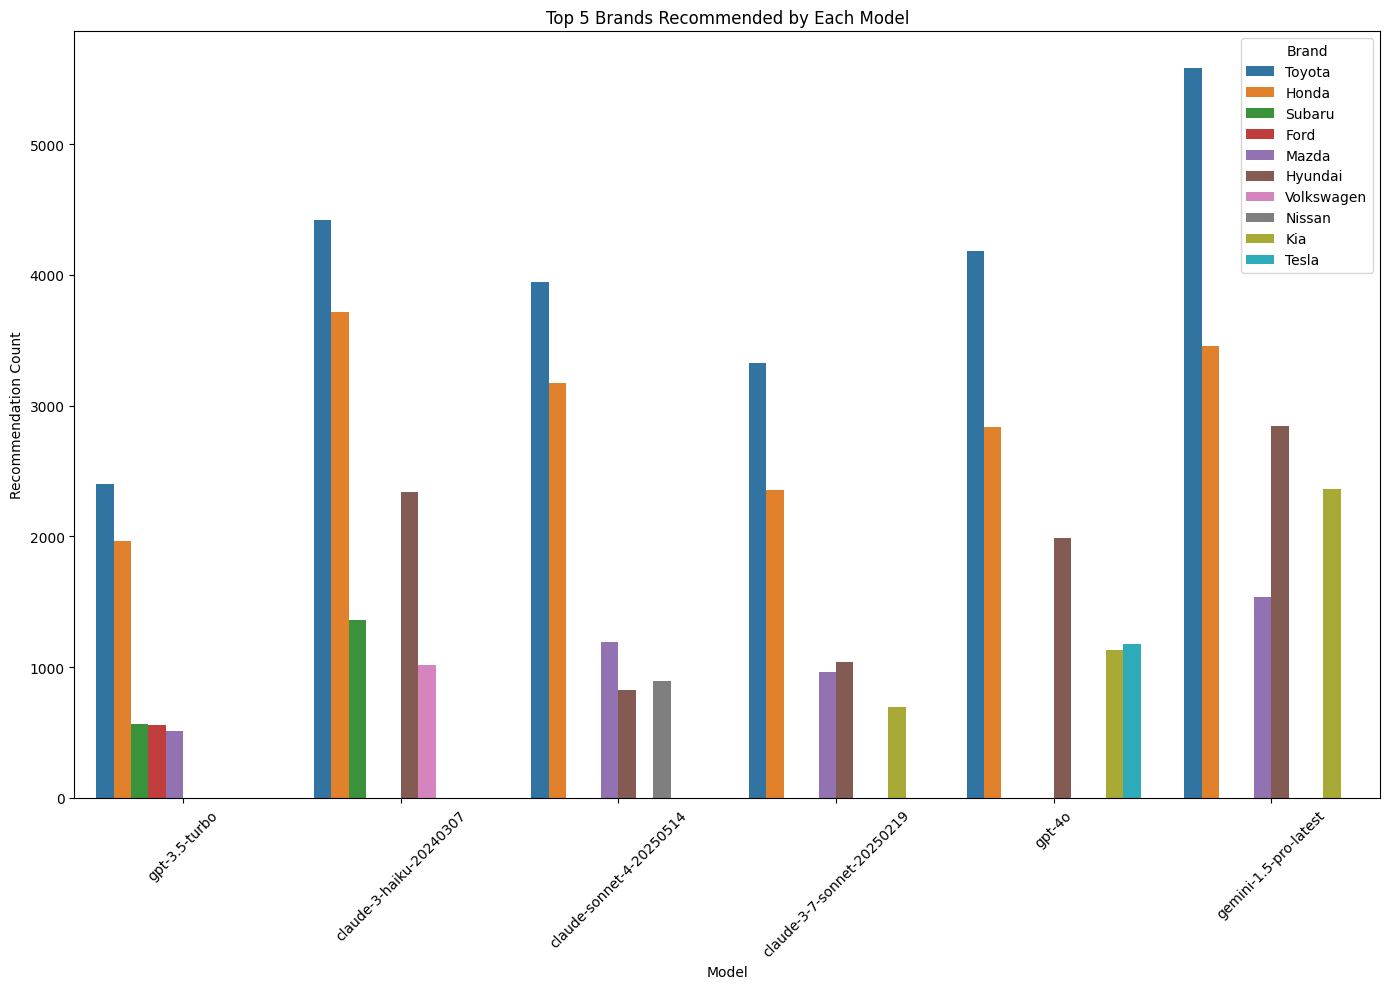

In [91]:
import json
from collections import Counter

# Function to extract brand from vehicle name (first word)
def extract_brand(vehicle_name):
    return vehicle_name.split()[0] if vehicle_name else None

# Dictionary to hold brand counts per model
brand_counts_per_model = {}

# Iterate through the dataframe
for index, row in df.iterrows():
    model = row['model']
    if pd.notna(row['llm_classifier_raw_json']):
        try:
            vehicles = json.loads(row['llm_classifier_raw_json'])['vehicles']
            brands = [extract_brand(v) for v in vehicles if extract_brand(v)]
            if model not in brand_counts_per_model:
                brand_counts_per_model[model] = Counter()
            brand_counts_per_model[model].update(brands)
        except (json.JSONDecodeError, KeyError):
            continue

# Create a summary dataframe for top brands per model
top_brands = []
for model, counter in brand_counts_per_model.items():
    most_common = counter.most_common(5)  # Top 5 brands per model
    for brand, count in most_common:
        top_brands.append({'model': model, 'brand': brand, 'count': count})

top_brands_df = pd.DataFrame(top_brands)

# Plot top brands per model
plt.figure(figsize=(14, 10))
sns.barplot(data=top_brands_df, x='model', y='count', hue='brand')
plt.title('Top 5 Brands Recommended by Each Model')
plt.xlabel('Model')
plt.ylabel('Recommendation Count')
plt.xticks(rotation=45)
plt.legend(title='Brand')
plt.tight_layout()
plt.show()

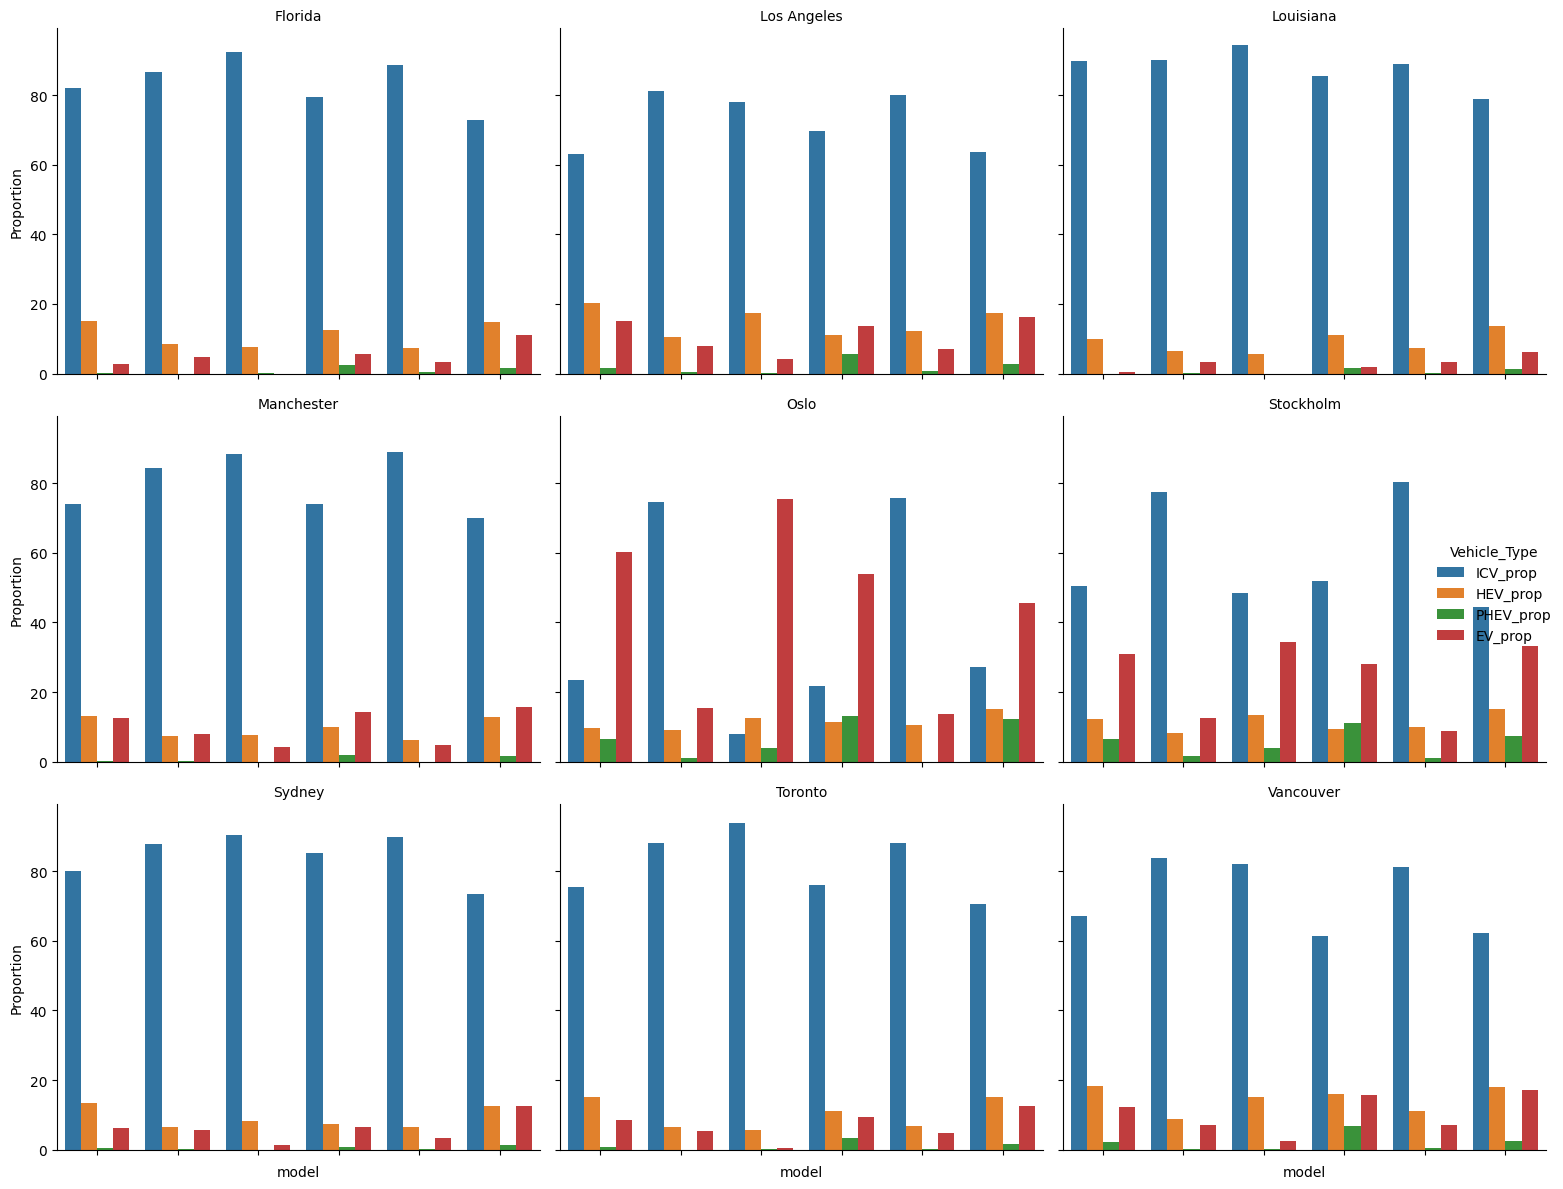

In [92]:
import re

# Function to extract city from prompt
def extract_city(prompt):
    match = re.search(r'I live in ([A-Za-z\s]+?)\s+and', prompt)
    if match:
        return match.group(1).strip().title()
    return None

# Add city column to df
df['city'] = df['original_prompt'].apply(extract_city)

# Filter for all cities (drop NaN)
df_filtered = df.dropna(subset=['city'])

# Parse JSON and extract counts for each vehicle type, now including city
data_regional = []
for index, row in df_filtered.iterrows():
    if pd.notna(row['llm_classifier_raw_json']):
        counts = json.loads(row['llm_classifier_raw_json'])['counts']
        data_regional.append({
            'city': row['city'],
            'model': row['model'],
            'ICV': counts.get('ICV', 0),
            'HEV': counts.get('HEV', 0),
            'PHEV': counts.get('PHEV', 0),
            'EV': counts.get('EV', 0)
        })

# Create a summary DataFrame and group by city and model
summary_regional_df = pd.DataFrame(data_regional)
grouped_regional = summary_regional_df.groupby(['city', 'model']).sum().reset_index()

# Calculate total suggestions per city-model
grouped_regional['Total'] = grouped_regional[['ICV', 'HEV', 'PHEV', 'EV']].sum(axis=1)

# Calculate proportions (as percentages)
grouped_regional['ICV_prop'] = (grouped_regional['ICV'] / grouped_regional['Total']) * 100
grouped_regional['HEV_prop'] = (grouped_regional['HEV'] / grouped_regional['Total']) * 100
grouped_regional['PHEV_prop'] = (grouped_regional['PHEV'] / grouped_regional['Total']) * 100
grouped_regional['EV_prop'] = (grouped_regional['EV'] / grouped_regional['Total']) * 100

# Melt the proportions for plotting
melted_regional_prop = grouped_regional.melt(id_vars=['city', 'model'], value_vars=['ICV_prop', 'HEV_prop', 'PHEV_prop', 'EV_prop'], var_name='Vehicle_Type', value_name='Proportion')

# Plot the bar graph with proportions, faceted by city
g = sns.catplot(data=melted_regional_prop, x='model', y='Proportion', hue='Vehicle_Type', col='city', kind='bar', height=4, aspect=1.2, col_wrap=3)
g.set_xticklabels(rotation=45)
g.set_titles("{col_name}")
plt.tight_layout()
plt.show()

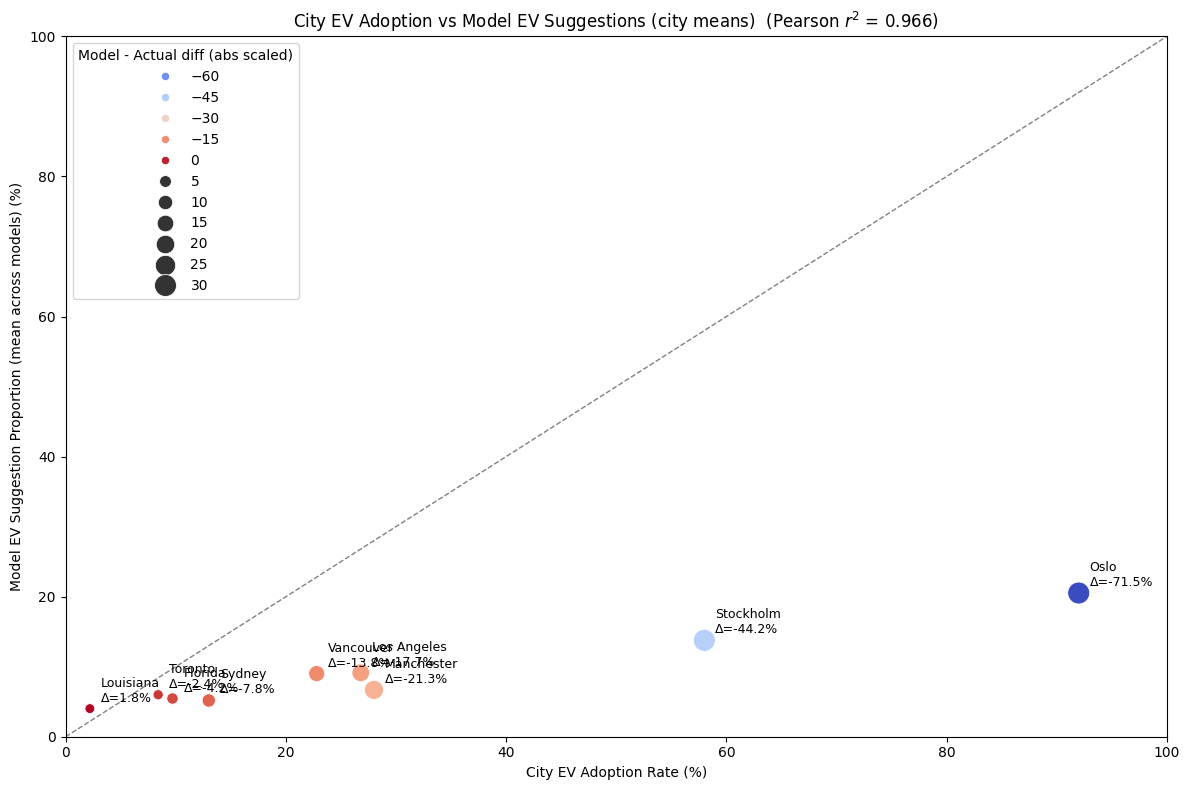

,city_norm,Model_EV_Mean,Adoption_Rate,Diff_Model_minus_Actual
4,Oslo,20.522730,92.0,-71.477270
5,Stockholm,13.755038,58.0,-44.244962
3,Manchester,6.687908,28.0,-21.312092
1,Los Angeles,9.127655,26.8,-17.672345
8,Vancouver,9.016756,22.8,-13.783244
6,Sydney,5.176304,13.0,-7.823696
0,Florida,5.456439,9.7,-4.243561
7,Toronto,5.997322,8.4,-2.402678
2,Louisiana,4.015066,2.2,1.815066



Top 5 cities where model overpredicts EVs:
   city_norm  Model_EV_Mean  Adoption_Rate  Diff_Model_minus_Actual
2  Louisiana       4.015066            2.2                 1.815066
7    Toronto       5.997322            8.4                -2.402678
0    Florida       5.456439            9.7                -4.243561
6     Sydney       5.176304           13.0                -7.823696
8  Vancouver       9.016756           22.8               -13.783244

Top 5 cities where model underpredicts EVs:
     city_norm  Model_EV_Mean  Adoption_Rate  Diff_Model_minus_Actual
4         Oslo      20.522730           92.0               -71.477270
5    Stockholm      13.755038           58.0               -44.244962
3   Manchester       6.687908           28.0               -21.312092
1  Los Angeles       9.127655           26.8               -17.672345
8    Vancouver       9.016756           22.8               -13.783244


In [93]:
# Labeled EV scatter: recompute melted_regional_prop if missing (and load df if kernel restarted)
import numpy as np
import json
import re
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# If df is missing in the kernel (kernel restart), try to load it from the repo data path
try:
    df
except NameError:
    repo_root = Path.cwd()
    csv_path = repo_root / 'data' / 'vehicle_prompt_results_joined_by_response.csv'
    if not csv_path.exists():
        csv_alt = Path.home() / 'Documents' / 'GitHub' / 'transformers_bert_llm_research' / 'data' / 'vehicle_prompt_results_joined_by_response.csv'
        if csv_alt.exists():
            csv_path = csv_alt
        else:
            raise FileNotFoundError(f'CSV not found at {csv_path} or {csv_alt}')
    df = pd.read_csv(csv_path)
    print('Loaded df from', csv_path)

# Mapping of real-world EV adoption rates (percent)
adoption_rates = {
    'Los Angeles': 26.8,
    'Louisiana': 2.2,
    'Florida': 9.7,
    'Toronto': 8.4,
    'Vancouver': 22.8,
    'Manchester': 28.0,
    'Sydney': 13.0,
    'Stockholm': 58.0,
    'Oslo': 92.0
}

# Helper to (re)compute melted_regional_prop
def compute_melted_regional_prop(df):
    def extract_city(prompt):
        m = re.search(r"I live in ([A-Za-z\s]+?)\s+and", str(prompt) or "")
        return m.group(1).strip().title() if m else None

    df_local = df.copy()
    df_local['city'] = df_local['original_prompt'].apply(extract_city)
    df_filtered = df_local.dropna(subset=['city'])

    data_regional = []
    for _, row in df_filtered.iterrows():
        jraw = row.get('llm_classifier_raw_json')
        if pd.notna(jraw) and jraw:
            try:
                j = json.loads(jraw)
            except Exception:
                continue
            counts = j.get('counts', {}) if isinstance(j, dict) else {}
            data_regional.append({
                'city': row['city'],
                'model': row['model'],
                'ICV': counts.get('ICV', 0),
                'HEV': counts.get('HEV', 0),
                'PHEV': counts.get('PHEV', 0),
                'EV': counts.get('EV', 0),
            })

    summary_regional_df = pd.DataFrame(data_regional)
    if summary_regional_df.empty:
        return pd.DataFrame(), pd.DataFrame()

    grouped_regional = summary_regional_df.groupby(['city','model']).sum().reset_index()
    grouped_regional['Total'] = grouped_regional[['ICV','HEV','PHEV','EV']].sum(axis=1)
    for vt in ['ICV','HEV','PHEV','EV']:
        grouped_regional[f'{vt}_prop'] = grouped_regional[vt] / grouped_regional['Total'] * 100

    melted = grouped_regional.melt(
        id_vars=['city','model'],
        value_vars=['ICV_prop','HEV_prop','PHEV_prop','EV_prop'],
        var_name='Vehicle_Type',
        value_name='Proportion'
    )
    return melted, grouped_regional

# Ensure melted_regional_prop exists or recompute
try:
    melted_regional_prop
except NameError:
    melted_regional_prop, grouped_regional = compute_melted_regional_prop(df)

# Select EV proportions
if melted_regional_prop.empty:
    raise RuntimeError('melted_regional_prop is empty after recompute; check raw JSON parsing')

ev_df = melted_regional_prop[melted_regional_prop['Vehicle_Type'].str.contains('EV', case=False)].copy()

# Normalize city names and map adoption rates
ev_df['city_norm'] = ev_df['city'].str.strip().str.title()
ev_df['adoption_rate'] = ev_df['city_norm'].map(adoption_rates)

# Drop rows without a provided adoption rate
ev_df = ev_df.dropna(subset=['adoption_rate'])

# Compute city-level mean proportion across models (for label placement) and overall model mean
city_means = ev_df.groupby('city_norm')['Proportion'].mean().reset_index().rename(columns={'Proportion':'Model_EV_Mean'})
model_means = ev_df.groupby('model')['Proportion'].mean().reset_index().rename(columns={'Proportion':'Model_EV_Mean'})

# Merge adoption rates to city_means and compute difference
city_means['Adoption_Rate'] = city_means['city_norm'].map(adoption_rates)
city_means['Diff_Model_minus_Actual'] = city_means['Model_EV_Mean'] - city_means['Adoption_Rate']

# Compute Pearson correlation (adoption_rate vs model EV proportion) using city means
x = city_means['Adoption_Rate'].values
y = city_means['Model_EV_Mean'].values
if len(x) >= 2:
    r = float(np.corrcoef(x, y)[0, 1])
    r2 = r ** 2
else:
    r = np.nan
    r2 = np.nan

# Plot: city points are the city-level means, colored by difference
plt.figure(figsize=(12, 8))
plt.axline((0,0), slope=1, linestyle='--', color='gray', linewidth=1)  # parity line

# Scatter city means
sns.scatterplot(data=city_means, x='Adoption_Rate', y='Model_EV_Mean',
                size=np.clip(np.abs(city_means['Diff_Model_minus_Actual']), 1, 30),
                hue='Diff_Model_minus_Actual', palette='coolwarm', legend='brief', sizes=(50, 250))

# Annotate each city with label and small table offset
for _, row in city_means.iterrows():
    plt.text(row['Adoption_Rate'] + 1.0, row['Model_EV_Mean'] + 1.0, f"{row['city_norm']}\nΔ={row['Diff_Model_minus_Actual']:.1f}%", fontsize=9)

plt.xlabel('City EV Adoption Rate (%)')
plt.ylabel('Model EV Suggestion Proportion (mean across models) (%)')
plt.title(f'City EV Adoption vs Model EV Suggestions (city means)  (Pearson $r^2$ = {r2:.3f})')
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.legend(title='Model - Actual diff (abs scaled)')
plt.tight_layout()
plt.show()

# Print a neat table of city comparisons
display(city_means.sort_values('Adoption_Rate', ascending=False))

# Also print top mismatches
print('\nTop 5 cities where model overpredicts EVs:')
print(city_means.sort_values('Diff_Model_minus_Actual', ascending=False).head(5))

print('\nTop 5 cities where model underpredicts EVs:')
print(city_means.sort_values('Diff_Model_minus_Actual', ascending=True).head(5))

Computed Pearson $r^2$ = 0.966 (n = 9)

EV suggestion averages per city per model (%):


model,claude-3-7-sonnet-20250219,claude-3-haiku-20240307,claude-sonnet-4-20250514,gemini-1.5-pro-latest,gpt-3.5-turbo,gpt-4o
city_norm,,,,,,
Florida,2.800830,4.893138,0.000000,5.672269,3.433476,11.003628
Los Angeles,15.101721,7.941010,4.136430,13.701578,6.956522,16.299822
Louisiana,0.436205,3.265766,0.000000,1.970443,3.309353,6.163022
Manchester,12.488084,7.972270,4.173228,14.143028,4.768583,15.812230
Oslo,60.141509,15.422886,75.474814,53.963839,13.703100,45.520757
Stockholm,30.813953,12.655738,34.394904,27.921536,8.689024,33.358321
Sydney,6.334842,5.568720,1.404287,6.503745,3.486924,12.515188
Toronto,8.630705,5.282784,0.465839,9.275478,4.791929,12.627169
Vancouver,12.324930,7.237220,2.520385,15.813775,7.133421,17.081851


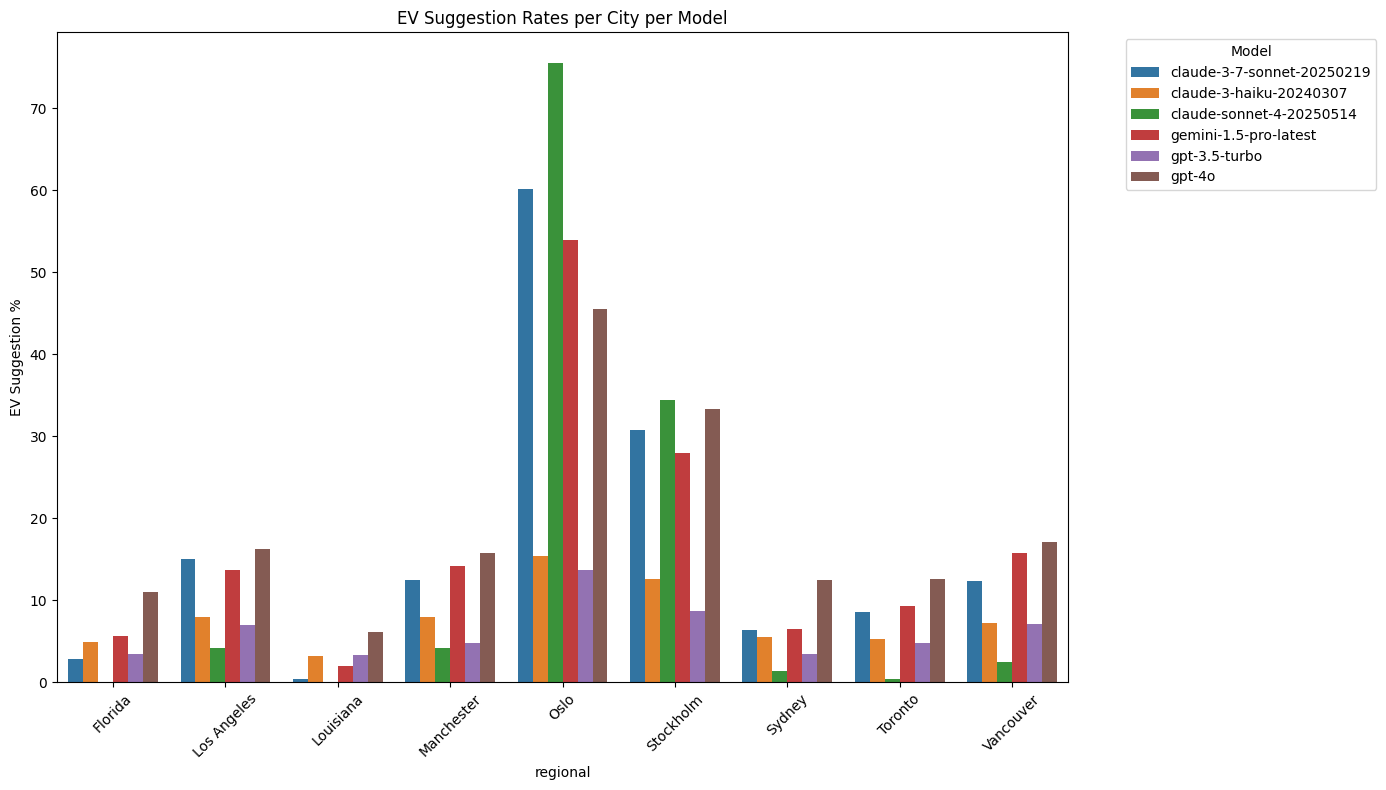

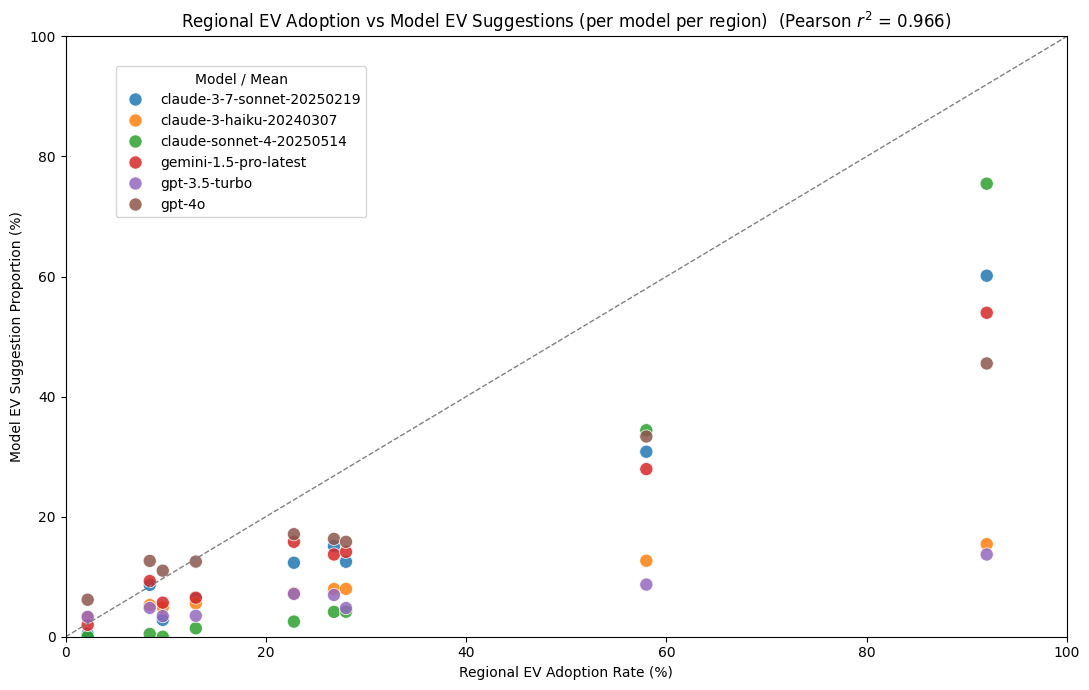

In [94]:
# Scatter: city-level real EV adoption vs model EV suggestion proportion (aggregated per city)

# Mapping of real-world EV adoption rates (percent)
adoption_rates = {
    'Los Angeles': 26.8,
    'Louisiana': 2.2,
    'Florida': 9.7,
    'Toronto': 8.4,
    'Vancouver': 22.8,
    'Manchester': 28.0,
    'Sydney': 13.0,
    'Stockholm': 58.0,
    'Oslo': 92.0
}

# Select EV proportions from the regional melted DataFrame
ev_df = melted_regional_prop[melted_regional_prop['Vehicle_Type'].str.contains('EV', case=False)].copy()

# Normalize city names and map adoption rates
ev_df['city_norm'] = ev_df['city'].str.strip().str.title()
ev_df['adoption_rate'] = ev_df['city_norm'].map(adoption_rates)

# Drop rows without a provided adoption rate
ev_df = ev_df.dropna(subset=['adoption_rate'])

# Compute per-city mean EV proportion across all models
city_means = ev_df.groupby('city_norm')['Proportion'].mean().reset_index().rename(columns={'Proportion': 'Model_EV_Mean'})
city_means['Adoption_Rate'] = city_means['city_norm'].map(adoption_rates)

# Compute Pearson correlation
x = city_means['Adoption_Rate'].values
y = city_means['Model_EV_Mean'].values
if len(x) >= 2:
    r = float(np.corrcoef(x, y)[0, 1])
    r2 = r ** 2
else:
    r = np.nan
    r2 = np.nan


# Annotate each city with label
for _, row in city_means.iterrows():
    plt.text(row['Adoption_Rate'] + 1.0, row['Model_EV_Mean'] + 1.0, row['city_norm'], fontsize=9)

# Print a short summary
print(f'Computed Pearson $r^2$ = {r2:.3f} (n = {len(city_means)})')

# Display EV suggestion averages per city per model
print('\nEV suggestion averages per city per model (%):')
display(pivot)

# Plot the different model EV suggestion rates per city
plt.figure(figsize=(14, 8))
sns.barplot(data=comp, x='city_norm', y='Model_City_EV_Mean', hue='model', palette='tab10')
plt.xticks(rotation=45)
plt.title('EV Suggestion Rates per City per Model')
plt.ylabel('EV Suggestion %')
plt.xlabel('regional')
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Compare to adoption rates: show city adoption rates alongside
adoption_df = pd.DataFrame(list(adoption_rates.items()), columns=['City', 'Adoption_Rate']).set_index('City')

# Add per-model per-city points to the existing scatterplot
plt.figure(figsize=(11, 7))
sns.scatterplot(data=comp, x='Adoption_Rate', y='Model_City_EV_Mean', hue='model', palette='tab10', s=90, edgecolor='w', linewidth=0.6, alpha=0.85, legend='brief')
# y = x reference line
plt.plot([0, 100], [0, 100], linestyle='--', color='gray', linewidth=1)
plt.xlabel('Regional EV Adoption Rate (%)')
plt.ylabel('Model EV Suggestion Proportion (%)')
plt.title(f'Regional EV Adoption vs Model EV Suggestions (per model per region)  (Pearson $r^2$ = {r2:.3f})')
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.legend(title='Model / Mean', bbox_to_anchor=(0.05, 0.95), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.show()

Total suggestions per model (top rows):


,model,ICV,HEV,PHEV,EV,Total,ICV_prop,HEV_prop,PHEV_prop,EV_prop
3,gemini-1.5-pro-latest,18119,3072,1401,4213,26805,67.595598,11.460548,5.226637,15.717217
1,claude-3-haiku-20240307,15168,1690,121,1401,18380,82.524483,9.194777,0.658324,7.622416
5,gpt-4o,10877,2753,611,3199,17440,62.368119,15.785550,3.503440,18.342890
2,claude-sonnet-4-20250514,10669,1696,153,2180,14698,72.588107,11.538985,1.040958,14.831950
0,claude-3-7-sonnet-20250219,7875,1810,356,2041,12082,65.179606,14.980963,2.946532,16.892899
4,gpt-3.5-turbo,6631,803,82,619,8135,81.511985,9.870928,1.007990,7.609096


Mean per-vehicle-type proportion per model (%):


Vehicle_Type,EV,HEV,ICV,PHEV,EV_Rank
model,,,,,
gpt-4o,19.065453,16.032328,61.338122,3.564097,1.0
claude-3-7-sonnet-20250219,17.016566,14.348228,65.990461,2.644745,2.0
gemini-1.5-pro-latest,16.486667,11.937352,66.338147,5.237834,3.0
claude-sonnet-4-20250514,15.152110,11.356835,72.524655,0.966400,4.0
llama3.2:latest,8.277922,10.027273,81.194805,0.500000,5.0
claude-3-haiku-20240307,6.863851,8.744409,83.736938,0.654802,6.0
gpt-3.5-turbo,6.470537,9.748272,82.884503,0.896689,7.0


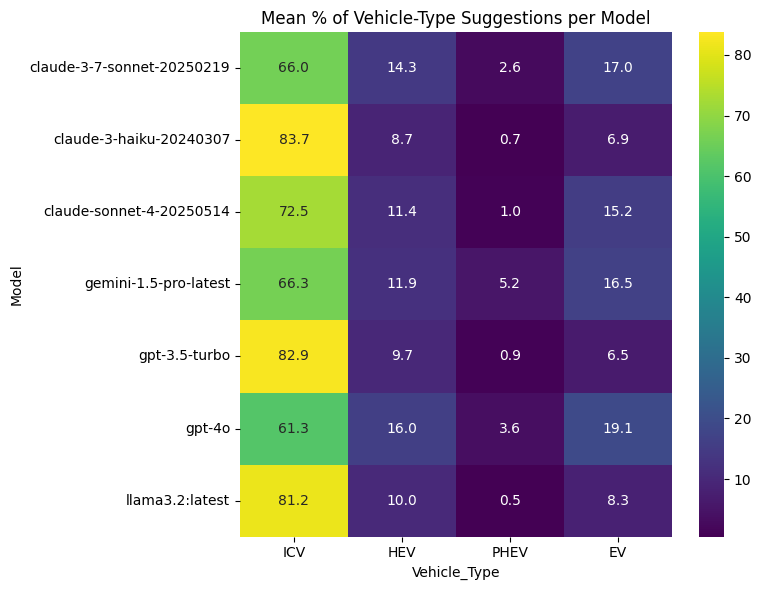

Pairwise t-tests for EV proportion (sorted by p-value):


,model_a,model_b,t_stat,p_value,n_a,n_b
2,claude-3-haiku-20240307,gpt-4o,-26.425502,6.464468e-139,1889,1916
16,gpt-4o,gpt-3.5-turbo,23.805632,2.298937e-116,1916,1660
3,claude-3-haiku-20240307,gemini-1.5-pro-latest,-19.495999,1.452373e-79,1889,1856
18,gemini-1.5-pro-latest,gpt-3.5-turbo,17.979689,3.867704e-69,1856,1660
1,claude-3-haiku-20240307,claude-3-7-sonnet-20250219,-16.418237,2.934581e-57,1889,1671
13,claude-3-7-sonnet-20250219,gpt-3.5-turbo,15.736619,1.690813e-53,1671,1660
0,claude-3-haiku-20240307,claude-sonnet-4-20250514,-12.443199,1.645493e-34,1889,1921
9,claude-sonnet-4-20250514,gpt-3.5-turbo,12.151980,3.390492e-33,1921,1660
7,claude-sonnet-4-20250514,gpt-4o,-5.288422,1.315085e-07,1921,1916
15,gpt-4o,gemini-1.5-pro-latest,4.374452,1.250657e-05,1916,1856


Per-model per-city mean differences (sample):


,model,city_norm,Model_City_Mean,City_Mean,Diff_Model_minus_City
22,claude-sonnet-4-20250514,Oslo,30.663364,20.522730,10.140634
31,gemini-1.5-pro-latest,Oslo,26.116520,20.522730,5.593790
4,claude-3-7-sonnet-20250219,Oslo,25.511006,20.522730,4.988276
50,gpt-4o,Stockholm,18.540730,13.755038,4.785691
35,gemini-1.5-pro-latest,Vancouver,12.889573,9.016756,3.872817
52,gpt-4o,Toronto,9.794534,5.997322,3.797212
49,gpt-4o,Oslo,24.277737,20.522730,3.755007
51,gpt-4o,Sydney,8.809235,5.176304,3.632930
45,gpt-4o,Florida,9.068924,5.456439,3.612485
53,gpt-4o,Vancouver,12.554369,9.016756,3.537613


In [81]:
# Per-model breakdowns: counts, mean proportions, EV ranking, heatmap, and pairwise tests
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from scipy import stats

# Ensure we have the per-prompt proportions dataframe (melted_prop_individual) or compute it if missing
try:
    melted_prop_individual
except NameError:
    # recompute from df similarly to earlier cells
    data_individual = []
    for index, row in df.iterrows():
        jraw = row.get('llm_classifier_raw_json')
        if pd.isna(jraw) or not jraw:
            continue
        try:
            j = json.loads(jraw)
        except Exception:
            continue
        counts = j.get('counts', {}) if isinstance(j, dict) else {}
        total = sum([v for v in counts.values() if isinstance(v, (int, float))])
        if total <= 0:
            continue
        for vt in ['ICV','HEV','PHEV','EV']:
            prop = counts.get(vt, 0) / total * 100
            data_individual.append({'model': row['model'], 'Vehicle_Type': vt, 'Proportion': prop})
    melted_prop_individual = pd.DataFrame(data_individual)

# Summary: total counts per model (from earlier grouped counts if available) or recompute counts
if 'grouped' in globals():
    counts_df = grouped.copy()
    counts_df['Total'] = counts_df[['ICV','HEV','PHEV','EV']].sum(axis=1)
else:
    # recompute counts per model from raw JSON
    rows = []
    for _, row in df.iterrows():
        jraw = row.get('llm_classifier_raw_json')
        if pd.isna(jraw) or not jraw:
            continue
        try:
            j = json.loads(jraw)
        except Exception:
            continue
        counts = j.get('counts', {}) if isinstance(j, dict) else {}
        rows.append({'model': row['model'], 'ICV': counts.get('ICV',0), 'HEV': counts.get('HEV',0), 'PHEV': counts.get('PHEV',0), 'EV': counts.get('EV',0)})
    counts_df = pd.DataFrame(rows).groupby('model').sum().reset_index()
    counts_df['Total'] = counts_df[['ICV','HEV','PHEV','EV']].sum(axis=1)

# Calculate per-model mean proportions (from per-prompt proportions)
model_means = melted_prop_individual.groupby(['model','Vehicle_Type'])['Proportion'].mean().reset_index().pivot(index='model', columns='Vehicle_Type', values='Proportion').fillna(0)
model_means['EV_Rank'] = model_means['EV'].rank(ascending=False, method='min')

# Display counts and model means
print('Total suggestions per model (top rows):')
display(counts_df.sort_values('Total', ascending=False).head(20))
print('Mean per-vehicle-type proportion per model (%):')
display(model_means.sort_values('EV', ascending=False))

# Heatmap of mean proportions across models and vehicle types
plt.figure(figsize=(8,6))
sns.heatmap(model_means[['ICV','HEV','PHEV','EV']], annot=True, fmt='.1f', cmap='viridis')
plt.title('Mean % of Vehicle-Type Suggestions per Model')
plt.ylabel('Model')
plt.tight_layout()
plt.show()

# Pairwise t-tests between models for EV proportion (using per-prompt EV proportions)
models = melted_prop_individual['model'].unique()
pair_tests = []
for a, b in combinations(models, 2):
    a_vals = melted_prop_individual[(melted_prop_individual['model']==a) & (melted_prop_individual['Vehicle_Type']=='EV')]['Proportion']
    b_vals = melted_prop_individual[(melted_prop_individual['model']==b) & (melted_prop_individual['Vehicle_Type']=='EV')]['Proportion']
    # require at least 2 samples in each group
    if len(a_vals) >= 2 and len(b_vals) >= 2:
        t_stat, p_val = stats.ttest_ind(a_vals, b_vals, equal_var=False, nan_policy='omit')
    else:
        t_stat, p_val = np.nan, np.nan
    pair_tests.append({'model_a': a, 'model_b': b, 't_stat': t_stat, 'p_value': p_val, 'n_a': len(a_vals), 'n_b': len(b_vals)})

pair_tests_df = pd.DataFrame(pair_tests).sort_values('p_value')
print('Pairwise t-tests for EV proportion (sorted by p-value):')
display(pair_tests_df.head(30))

# Per-city differences summary: for each model, compute mean EV proportion per city and compare to city mean across models
if 'melted_regional_prop' in globals():
    ev_regional = melted_regional_prop[melted_regional_prop['Vehicle_Type'].str.contains('EV', case=False)].copy()
    ev_regional['city_norm'] = ev_regional['city'].str.strip().str.title()
    city_overall = ev_regional.groupby('city_norm')['Proportion'].mean().reset_index().rename(columns={'Proportion':'City_Mean'})
    model_city = ev_regional.groupby(['model','city_norm'])['Proportion'].mean().reset_index().rename(columns={'Proportion':'Model_City_Mean'})
    merged = model_city.merge(city_overall, on='city_norm', how='left')
    merged['Diff_Model_minus_City'] = merged['Model_City_Mean'] - merged['City_Mean']
    print('Per-model per-city mean differences (sample):')
    display(merged.sort_values('Diff_Model_minus_City', ascending=False).head(20))
else:
    print('Skipped per-city breakdown because melted_regional_prop is not available in the kernel.')

# End of per-model breakdown cell

In [82]:
# Per-model, per-city EV suggestions vs provided adoption rates (fixed EV selection)
import pandas as pd
import numpy as np
import json, re
from pathlib import Path

# Reuse adoption_rates mapping from earlier cells; redefine here to be safe
adoption_rates = {
    'Los Angeles': 26.8,
    'Louisiana': 2.2,
    'Florida': 9.7,
    'Toronto': 8.4,
    'Vancouver': 22.8,
    'Manchester': 28.0,
    'Sydney': 13.0,
    'Stockholm': 58.0,
    'Oslo': 92.0,
}

# Ensure we have regional melted data; recompute if missing. This returns long-form rows
# with columns: city, model, Vehicle_Type, Proportion (percentage)
def compute_melted_regional_prop_local(df):
    def extract_city(prompt):
        m = re.search(r"I live in ([A-Za-z\s]+?)\s+and", str(prompt) or "")
        return m.group(1).strip().title() if m else None

    df_local = df.copy()
    df_local['city'] = df_local['original_prompt'].apply(extract_city)
    df_filtered = df_local.dropna(subset=['city'])

    rows = []
    for _, row in df_filtered.iterrows():
        jraw = row.get('llm_classifier_raw_json')
        if pd.isna(jraw) or not jraw:
            continue
        try:
            j = json.loads(jraw)
        except Exception:
            continue
        counts = j.get('counts', {}) if isinstance(j, dict) else {}
        total = sum([v for v in counts.values() if isinstance(v, (int, float))])
        if total <= 0:
            continue
        # produce long-form Vehicle_Type / Proportion rows
        for vt in ['ICV', 'HEV', 'PHEV', 'EV']:
            prop = counts.get(vt, 0) / total * 100
            rows.append({
                'city': row['city'],
                'model': row['model'],
                'Vehicle_Type': vt,
                'Proportion': prop,
            })
    return pd.DataFrame(rows)

try:
    # if kernel already has melted_regional_prop (long form) this will pass
    melted_regional_prop
except NameError:
    # If df is missing, try to load it from the repo
    try:
        df
    except NameError:
        repo_root = Path.cwd()
        csv_path = repo_root / 'data' / 'vehicle_prompt_results_joined_by_response.csv'
        if not csv_path.exists():
            csv_alt = Path.home() / 'Documents' / 'GitHub' / 'transformers_bert_llm_research' / 'data' / 'vehicle_prompt_results_joined_by_response.csv'
            if csv_alt.exists():
                csv_path = csv_alt
            else:
                raise FileNotFoundError(f'CSV not found at {csv_path} or {csv_alt}')
        df = pd.read_csv(csv_path)
    # recompute the long-form regional proportions dataframe
    melt_reg_df = compute_melted_regional_prop_local(df)
    # set the familiar variable name used elsewhere
    melted_regional_prop = melt_reg_df.copy()

# Debug info: show sizes and a small sample to diagnose blank output
print('melted_regional_prop rows:', len(melted_regional_prop))
print('melted_regional_prop columns:', list(melted_regional_prop.columns))
display(melted_regional_prop.head())

# Now compute per-model, per-city EV means using the long-form melted schema
ev_regional = melted_regional_prop.copy()
ev_regional['city_norm'] = ev_regional['city'].str.strip().str.title()
# Normalize Vehicle_Type (handle both 'EV' and 'EV_prop' naming conventions) and select EV rows robustly
ev_regional['Vehicle_Type_norm'] = ev_regional['Vehicle_Type'].astype(str).str.replace('_prop', '', case=False).str.strip().str.upper()
ev_only = ev_regional[ev_regional['Vehicle_Type_norm'] == 'EV'].copy()
print("Note: Vehicle_Type values were normalized to 'Vehicle_Type_norm' to handle both 'EV' and 'EV_prop' naming; this prevents empty EV selections caused by naming mismatches.")

print('EV-only rows:', len(ev_only))
display(ev_only.head())

model_city_means = ev_only.groupby(['model','city_norm'])['Proportion'].mean().reset_index().rename(columns={'Proportion':'Model_City_EV_Mean'})
print('model_city_means rows:', len(model_city_means))
display(model_city_means.head())

city_overall = ev_only.groupby('city_norm')['Proportion'].mean().reset_index().rename(columns={'Proportion':'City_EV_Mean'})
print('city_overall rows:', len(city_overall))
display(city_overall.head())

merged = model_city_means.merge(city_overall, on='city_norm', how='left')
merged['Adoption_Rate'] = merged['city_norm'].map(adoption_rates)
merged['Diff_Model_minus_Actual'] = merged['Model_City_EV_Mean'] - merged['Adoption_Rate']
print('merged rows:', len(merged))
display(merged.head())

# Keep only cities where we have an adoption rate to compare
comp = merged.dropna(subset=['Adoption_Rate']).copy()
print('comp (rows with adoption rates):', len(comp))
display(comp.head())

# Summary tables: per model average diff across provided cities, and per-model per-city sample
model_summary = comp.groupby('model')['Diff_Model_minus_Actual'].agg(['mean','median','count']).reset_index().rename(columns={'mean':'Mean_Diff','median':'Median_Diff','count':'Cities_Compared'})
model_summary['Mean_Diff'] = model_summary['Mean_Diff'].round(2)
model_summary = model_summary.sort_values('Mean_Diff', ascending=False)

print('Per-model summary vs provided adoption rates (positive = model predicts higher EV % than actual):')
display(model_summary)

print('Sample of per-model per-city comparisons (top mismatches):')
display(comp.sort_values('Diff_Model_minus_Actual', ascending=False).head(50))

# Optionally: pivot table for a compact view (models as columns, cities as rows)
pivot = comp.pivot_table(index='city_norm', columns='model', values='Model_City_EV_Mean')
print('Pivot: city × model EV mean (subset)')
display(pivot.head(20))

# End of per-model per-city comparison cell

melted_regional_prop rows: 216
melted_regional_prop columns: ['city', 'model', 'Vehicle_Type', 'Proportion']


,city,model,Vehicle_Type,Proportion
0,Florida,claude-3-7-sonnet-20250219,ICV_prop,81.950207
1,Florida,claude-3-haiku-20240307,ICV_prop,86.670416
2,Florida,claude-sonnet-4-20250514,ICV_prop,92.302358
3,Florida,gemini-1.5-pro-latest,ICV_prop,79.369748
4,Florida,gpt-3.5-turbo,ICV_prop,88.698140


Note: Vehicle_Type values were normalized to 'Vehicle_Type_norm' to handle both 'EV' and 'EV_prop' naming; this prevents empty EV selections caused by naming mismatches.
EV-only rows: 54


,city,model,Vehicle_Type,Proportion,city_norm,Vehicle_Type_norm
162,Florida,claude-3-7-sonnet-20250219,EV_prop,2.800830,Florida,EV
163,Florida,claude-3-haiku-20240307,EV_prop,4.893138,Florida,EV
164,Florida,claude-sonnet-4-20250514,EV_prop,0.000000,Florida,EV
165,Florida,gemini-1.5-pro-latest,EV_prop,5.672269,Florida,EV
166,Florida,gpt-3.5-turbo,EV_prop,3.433476,Florida,EV


model_city_means rows: 54


,model,city_norm,Model_City_EV_Mean
0,claude-3-7-sonnet-20250219,Florida,2.800830
1,claude-3-7-sonnet-20250219,Los Angeles,15.101721
2,claude-3-7-sonnet-20250219,Louisiana,0.436205
3,claude-3-7-sonnet-20250219,Manchester,12.488084
4,claude-3-7-sonnet-20250219,Oslo,60.141509


city_overall rows: 9


,city_norm,City_EV_Mean
0,Florida,4.633890
1,Los Angeles,10.689514
2,Louisiana,2.524131
3,Manchester,9.892904
4,Oslo,44.037817


merged rows: 54


,model,city_norm,Model_City_EV_Mean,City_EV_Mean,Adoption_Rate,Diff_Model_minus_Actual
0,claude-3-7-sonnet-20250219,Florida,2.800830,4.633890,9.7,-6.899170
1,claude-3-7-sonnet-20250219,Los Angeles,15.101721,10.689514,26.8,-11.698279
2,claude-3-7-sonnet-20250219,Louisiana,0.436205,2.524131,2.2,-1.763795
3,claude-3-7-sonnet-20250219,Manchester,12.488084,9.892904,28.0,-15.511916
4,claude-3-7-sonnet-20250219,Oslo,60.141509,44.037817,92.0,-31.858491


comp (rows with adoption rates): 54


,model,city_norm,Model_City_EV_Mean,City_EV_Mean,Adoption_Rate,Diff_Model_minus_Actual
0,claude-3-7-sonnet-20250219,Florida,2.800830,4.633890,9.7,-6.899170
1,claude-3-7-sonnet-20250219,Los Angeles,15.101721,10.689514,26.8,-11.698279
2,claude-3-7-sonnet-20250219,Louisiana,0.436205,2.524131,2.2,-1.763795
3,claude-3-7-sonnet-20250219,Manchester,12.488084,9.892904,28.0,-15.511916
4,claude-3-7-sonnet-20250219,Oslo,60.141509,44.037817,92.0,-31.858491


Per-model summary vs provided adoption rates (positive = model predicts higher EV % than actual):


,model,Mean_Diff,Median_Diff,Cities_Compared
5,gpt-4o,-10.06,-5.718149,9
0,claude-3-7-sonnet-20250219,-12.43,-10.475070,9
3,gemini-1.5-pro-latest,-12.44,-6.986225,9
2,claude-sonnet-4-20250514,-15.37,-16.525186,9
1,claude-3-haiku-20240307,-21.18,-15.562780,9
4,gpt-3.5-turbo,-22.74,-15.666579,9


Sample of per-model per-city comparisons (top mismatches):


,model,city_norm,Model_City_EV_Mean,City_EV_Mean,Adoption_Rate,Diff_Model_minus_Actual
52,gpt-4o,Toronto,12.627169,6.845651,8.4,4.227169
47,gpt-4o,Louisiana,6.163022,2.524131,2.2,3.963022
45,gpt-4o,Florida,11.003628,4.633890,9.7,1.303628
38,gpt-3.5-turbo,Louisiana,3.309353,2.524131,2.2,1.109353
11,claude-3-haiku-20240307,Louisiana,3.265766,2.524131,2.2,1.065766
34,gemini-1.5-pro-latest,Toronto,9.275478,6.845651,8.4,0.875478
7,claude-3-7-sonnet-20250219,Toronto,8.630705,6.845651,8.4,0.230705
29,gemini-1.5-pro-latest,Louisiana,1.970443,2.524131,2.2,-0.229557
51,gpt-4o,Sydney,12.515188,5.968951,13.0,-0.484812
2,claude-3-7-sonnet-20250219,Louisiana,0.436205,2.524131,2.2,-1.763795


Pivot: city × model EV mean (subset)


model,claude-3-7-sonnet-20250219,claude-3-haiku-20240307,claude-sonnet-4-20250514,gemini-1.5-pro-latest,gpt-3.5-turbo,gpt-4o
city_norm,,,,,,
Florida,2.800830,4.893138,0.000000,5.672269,3.433476,11.003628
Los Angeles,15.101721,7.941010,4.136430,13.701578,6.956522,16.299822
Louisiana,0.436205,3.265766,0.000000,1.970443,3.309353,6.163022
Manchester,12.488084,7.972270,4.173228,14.143028,4.768583,15.812230
Oslo,60.141509,15.422886,75.474814,53.963839,13.703100,45.520757
Stockholm,30.813953,12.655738,34.394904,27.921536,8.689024,33.358321
Sydney,6.334842,5.568720,1.404287,6.503745,3.486924,12.515188
Toronto,8.630705,5.282784,0.465839,9.275478,4.791929,12.627169
Vancouver,12.324930,7.237220,2.520385,15.813775,7.133421,17.081851


# Sustainability Viewpoint

Overall totals by vehicle type:
  Vehicle_Type  Count    Percent
0          ICV  69339  71.087759
1          HEV  11824  12.122206
2         PHEV   2724   2.792700
3           EV  13653  13.997334


/var/folders/6k/54vwstl13q19y8fhffrsh27w0000gp/T/ipykernel_10527/4152016119.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=overall_df, x='Vehicle_Type', y='Count', palette='muted')


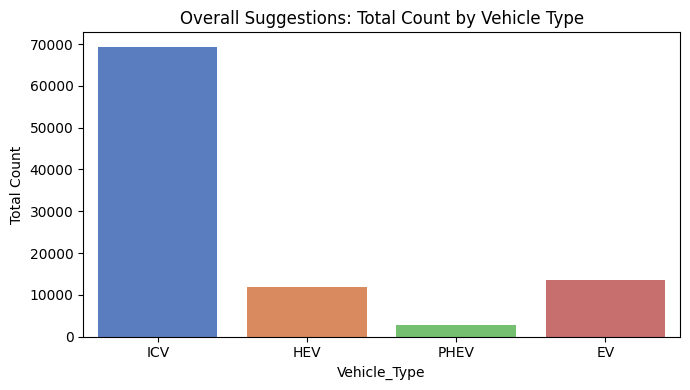

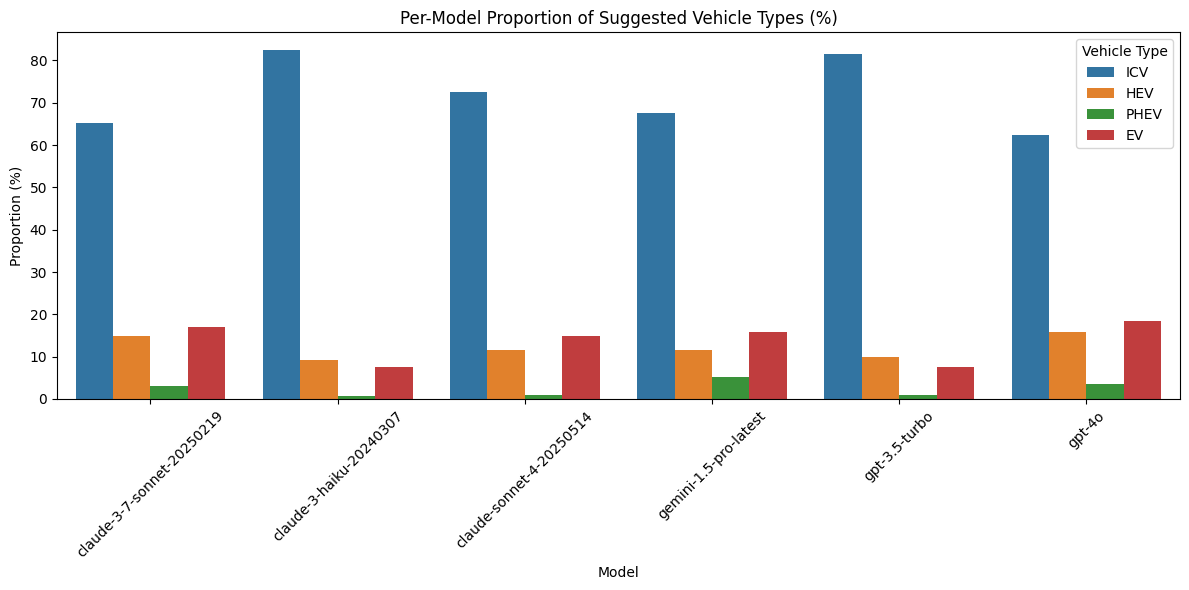

/var/folders/6k/54vwstl13q19y8fhffrsh27w0000gp/T/ipykernel_10527/4152016119.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=melted_prop_individual, x='Vehicle_Type', y='Proportion', palette='pastel')


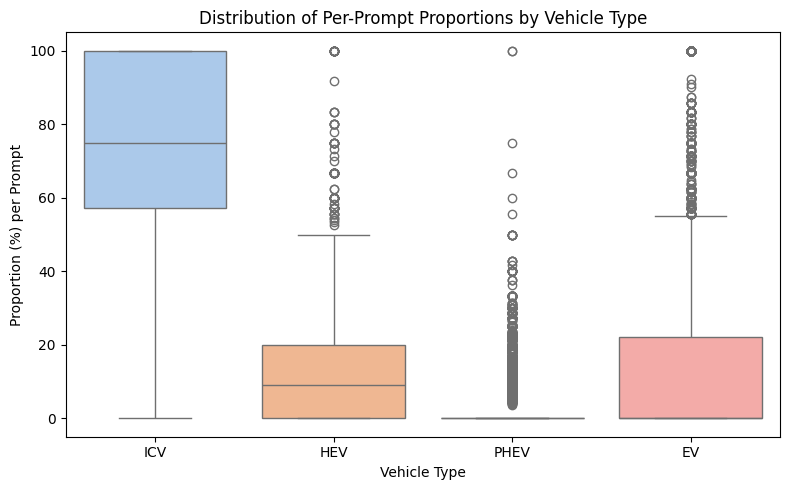


Per-prompt proportion summary (by vehicle type):
                count       mean        std  min        25%        50%  \
Vehicle_Type                                                             
EV            10938.0  13.584238  20.015797  0.0   0.000000   0.000000   
HEV           10938.0  12.033008  13.591779  0.0   0.000000   9.090909   
ICV           10938.0  72.045583  28.796546  0.0  57.142857  75.000000   
PHEV          10938.0   2.337171   6.560240  0.0   0.000000   0.000000   

                     75%    max  
Vehicle_Type                     
EV             22.222222  100.0  
HEV            20.000000  100.0  
ICV           100.000000  100.0  
PHEV            0.000000  100.0  


In [83]:
# Compare suggestions across all vehicle types: overall totals, per-model proportions, and per-prompt distributions.

# Overall totals and percentages across all models
overall_counts = grouped[['ICV', 'HEV', 'PHEV', 'EV']].sum()
overall_df = overall_counts.reset_index()
overall_df.columns = ['Vehicle_Type', 'Count']
overall_df['Percent'] = overall_df['Count'] / overall_df['Count'].sum() * 100
print("Overall totals by vehicle type:")
print(overall_df)

# Plot overall totals
plt.figure(figsize=(7, 4))
sns.barplot(data=overall_df, x='Vehicle_Type', y='Count', palette='muted')
plt.title('Overall Suggestions: Total Count by Vehicle Type')
plt.ylabel('Total Count')
plt.tight_layout()
plt.show()

# Per-model proportions (from aggregated counts in `melted`)
# Compute per-model proportion (%) from the counts
melted_prop2 = melted.copy()
melted_prop2['Proportion'] = melted_prop2.groupby('model')['Count'].transform(lambda s: s / s.sum() * 100)

plt.figure(figsize=(12, 6))
sns.barplot(data=melted_prop2, x='model', y='Proportion', hue='Vehicle_Type')
plt.title('Per-Model Proportion of Suggested Vehicle Types (%)')
plt.ylabel('Proportion (%)')
plt.xlabel('Model')
plt.xticks(rotation=45)
plt.legend(title='Vehicle Type')
plt.tight_layout()
plt.show()

# Distribution of per-prompt proportions across vehicle types (using `melted_prop_individual`)
plt.figure(figsize=(8, 5))
sns.boxplot(data=melted_prop_individual, x='Vehicle_Type', y='Proportion', palette='pastel')
plt.title('Distribution of Per-Prompt Proportions by Vehicle Type')
plt.ylabel('Proportion (%) per Prompt')
plt.xlabel('Vehicle Type')
plt.tight_layout()
plt.show()

# Print simple statistics for per-prompt proportions
print("\nPer-prompt proportion summary (by vehicle type):")
print(melted_prop_individual.groupby('Vehicle_Type')['Proportion'].describe())

# Anova

In [84]:
from statsmodels.formula.api import ols
import pandas as pd
import statsmodels.api as sm
import json

# Create data at the prompt level for proportions
data_individual = []
for index, row in df.iterrows():
    if pd.notna(row['llm_classifier_raw_json']):
        counts = json.loads(row['llm_classifier_raw_json'])['counts']
        total = sum(counts.values())
        if total > 0:
            for vt in ['ICV', 'HEV', 'PHEV', 'EV']:
                prop = counts.get(vt, 0) / total * 100
                data_individual.append({
                    'model': row['model'],
                    'Vehicle_Type': vt,
                    'Proportion': prop
                })

melted_prop_individual = pd.DataFrame(data_individual)

# List of vehicle types
vehicle_types = ['ICV', 'HEV', 'PHEV', 'EV']

# Initialize a list to store ANOVA results
anova_results = []

for vt in vehicle_types:
    # Filter data for the current vehicle type
    data_subset = melted_prop_individual[melted_prop_individual['Vehicle_Type'] == vt]
    
    # Drop any rows with NaN in Proportion (though shouldn't be)
    data_subset = data_subset.dropna(subset=['Proportion'])
    
    # Perform ANOVA
    model_anova = ols('Proportion ~ model', data=data_subset).fit()
    anova_table = sm.stats.anova_lm(model_anova, typ=2)
    
    # Extract F-statistic and p-value
    f_stat = anova_table['F'][0]
    p_value = anova_table['PR(>F)'][0]
    
    # Append to results
    anova_results.append({
        'Vehicle_Type': vt,
        'F_Statistic': f_stat,
        'P_Value': p_value
    })

# Create a DataFrame for the ANOVA table
anova_df = pd.DataFrame(anova_results)

# Display the table
print(anova_df)

  Vehicle_Type  F_Statistic        P_Value
0          ICV   209.866991  2.200768e-214
1          HEV    77.935328   1.415113e-80
2         PHEV   154.191771  8.974791e-159
3           EV   141.638558  4.627873e-146


/var/folders/6k/54vwstl13q19y8fhffrsh27w0000gp/T/ipykernel_10527/1447397869.py:41: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  f_stat = anova_table['F'][0]
/var/folders/6k/54vwstl13q19y8fhffrsh27w0000gp/T/ipykernel_10527/1447397869.py:42: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value = anova_table['PR(>F)'][0]
/var/folders/6k/54vwstl13q19y8fhffrsh27w0000gp/T/ipykernel_10527/1447397869.py:41: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `se

# Violin plots

In [95]:
import seaborn as sns
import re

import matplotlib.pyplot as plt

# Function to determine if the starting vehicle in the prompt is an EV
def is_starting_ev(prompt):
    if not isinstance(prompt, str):
        return False
    # Extract vehicle name after "my " or similar
    m = re.search(r'my\s+([A-Za-z\s]+?)\s+finally', prompt.lower())
    if m:
        vehicle = m.group(1).strip()
        # List of known EV models/brands (expand as needed based on data)
        ev_vehicles = ['tesla', 'bolt', 'leaf', 'model s', 'model 3', 'model x', 'model y', 'ioniq', 'kona electric', 'e-tron', 'id.3', 'id.4', 'polestar', 'mach-e', 'mustang mach-e', 'f-150 lightning', 'rivian', 'cybertruck', 'bz4x', 'ariya', 'eqb', 'eqc', 'eqs', 'eqv', 'e-class', 'c-class electric', 'a-class electric']
        if any(ev.lower() in vehicle.lower() for ev in ev_vehicles):
            return True
    return False

# Add column to plot_df indicating if starting car is EV
plot_df['starting_is_ev'] = plot_df['original_prompt'].apply(is_starting_ev)

# Filter for valid EV_pct (drop NaN)
plot_df_filtered = plot_df.dropna(subset=['EV_pct'])

# Violin plot: EV recommendation % when starting car is EV vs not EV
plt.figure(figsize=(8, 6))
sns.violinplot(data=plot_df_filtered, x='starting_is_ev', y='EV_pct', palette='muted', cut=0)
plt.xlabel('Starting Car is EV')
plt.ylabel('EV Recommendation %')
plt.title('Violin Plot: EV Recommendation % When Starting Car is EV vs Not EV')
plt.xticks([0, 1], ['Not EV', 'EV'])
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

# Optional: Summary statistics
summary = plot_df_filtered.groupby('starting_is_ev')['EV_pct'].agg(['count', 'mean', 'median', 'std']).reset_index()
summary['starting_is_ev'] = summary['starting_is_ev'].map({False: 'Not EV', True: 'EV'})
print("Summary of EV Recommendation % by Starting Car Type:")
print(summary)

NameError: name 'plot_df' is not defined

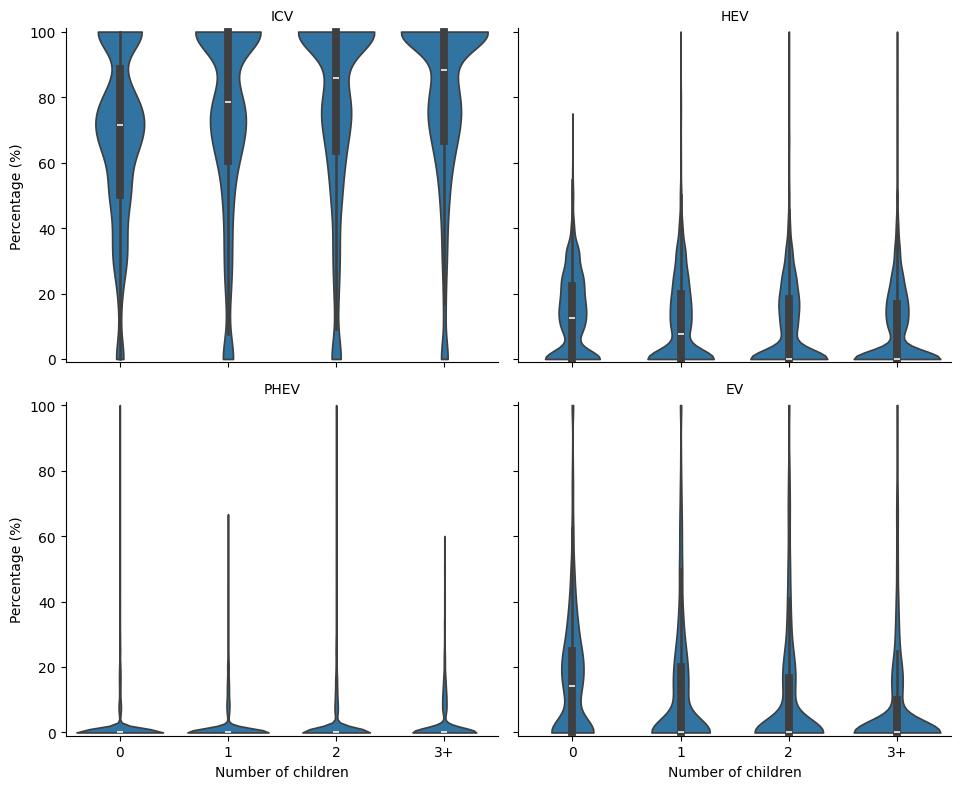

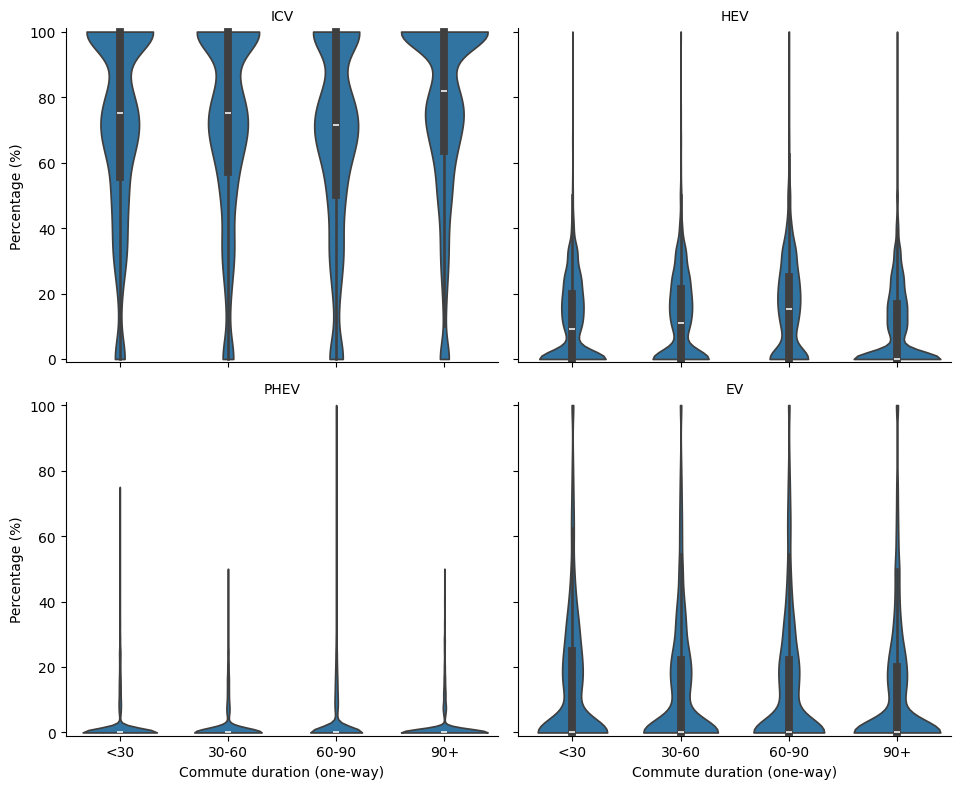

In [ ]:
import math

# Improved children parsing to capture more variants: digits, words, 'kid(s)', 'my 2 kids', 'we have two kids', 'kids: 2', 'no kids', etc.
word2num_map = {
    'zero': 0, 'none': 0, 'no': 0, 'one': 1, 'two': 2, 'three': 3, 'four': 4,
    'five': 5, 'six': 6, 'seven': 7, 'eight': 8, 'nine': 9, 'ten': 10
}

# Accepts a prompt string and returns an int number of children or math.nan if unknown
def parse_num_children(prompt):
    if not isinstance(prompt, str):
        return math.nan
    s = prompt.lower()
    # Common patterns like 'i have 2 kids', 'we have two children', 'my 2 kids', 'kids: 2', '2 kids', 'no kids'
    # 1) explicit digits with kid/kids/child/children
    m = re.search(r"(\d{1,2})\s*(?:kids|kid|children|child)\b", s)
    if m:
        try:
            val = int(m.group(1))
            return val
        except Exception:
            pass
    # 2) patterns like 'i have two kids' or 'we have one child'
    m = re.search(r"(?:i|we|my|has|have|having|our|us)\s+(?:got\s+)?(zero|one|two|three|four|five|six|seven|eight|nine|ten|no|none)\s*(?:kids|kid|children|child)\b", s)
    if m:
        word = m.group(1)
        return word2num_map.get(word, math.nan)
    # 3) patterns like 'kids: 2' or 'children: 3'
    m = re.search(r"(?:kids|children|child|kid)\s*[:\-]\s*(\d{1,2})\b", s)
    if m:
        try:
            return int(m.group(1))
        except Exception:
            pass
    # 4) 'no kids' or 'no children' or 'no child'
    if re.search(r"\b(no\s+kids|no\s+children|no\s+child|no\s+kid)\b", s):
        return 0
    # 5) standalone word numbers like 'two kids' (without preceding 'i have')
    m = re.search(r"\b(one|two|three|four|five|six|seven|eight|nine|ten)\b\s*(?:kids|kid|children|child)\b", s)
    if m:
        return word2num_map.get(m.group(1), math.nan)
    # 6) 'we have x children' more generic
    m = re.search(r"we\s+have\s+(\d{1,2})\s*(?:kids|children|child|kid)\b", s)
    if m:
        try:
            return int(m.group(1))
        except Exception:
            pass
    # 7) 'two kids and' or 'kids (2)'
    m = re.search(r"\((\d{1,2})\)\s*(?:kids|children|child|kid)?", s)
    if m:
        try:
            return int(m.group(1))
        except Exception:
            pass
    # If nothing matched, return NaN
    return math.nan

# Improved commute parser remains the same (keeps previous behavior)
def parse_commute_minutes(prompt):
    if not isinstance(prompt, str):
        return math.nan
    s = prompt.lower()
    # look for patterns like "for 1 hour", "for 1.5 hours", "for 30 minutes", "... 1 hour one way"
    m = re.search(r'for\s+(\d+(?:\.\d+)?)\s*(hours|hour|hrs|hr|h)\b', s)
    if m:
        return float(m.group(1)) * 60
    m = re.search(r'for\s+(\d+(?:\.\d+)?)\s*(minutes|minute|mins|min)\b', s)
    if m:
        return float(m.group(1))
    # fallback: "commute .* (\d+)h" or "(\d+)m"
    m = re.search(r'commut.*\s+(\d+(?:\.\d+)?)\s*h\b', s)
    if m:
        return float(m.group(1)) * 60
    m = re.search(r'commut.*\s+(\d+(?:\.\d+)?)\s*m\b', s)
    if m:
        return float(m.group(1))
    return math.nan

# --- Build per-prompt vehicle-type proportions (indexed by original df index) ---
rows = []
for idx, row in df.iterrows():
    jraw = row.get('llm_classifier_raw_json')
    if pd.isna(jraw) or not jraw:
        continue
    try:
        j = json.loads(jraw)
        counts = j.get('counts', {}) if isinstance(j, dict) else {}
        # ensure numeric values
        total = sum([v for v in counts.values() if isinstance(v, (int, float))])
        if total <= 0:
            continue
        rows.append({
            'index': idx,
            'model': row.get('model'),
            'original_prompt': row.get('original_prompt',''),
            'ICV_pct': counts.get('ICV', 0) / total * 100,
            'HEV_pct': counts.get('HEV', 0) / total * 100,
            'PHEV_pct': counts.get('PHEV', 0) / total * 100,
            'EV_pct': counts.get('EV', 0) / total * 100
        })
    except Exception:
        continue

per_prompt_props = pd.DataFrame(rows).set_index('index')

# --- Parse children & commute from prompts and merge ---
parsed = pd.DataFrame({
    'index': df.index,
    'num_children': df['original_prompt'].apply(parse_num_children),
    'commute_minutes': df['original_prompt'].apply(parse_commute_minutes)
}).set_index('index')

plot_df = per_prompt_props.join(parsed, how='inner').reset_index()

# Drop rows with no relevant parsed data
plot_df = plot_df.dropna(subset=['EV_pct'])

# Create categorical children buckets

def children_bucket(n):
    try:
        n = int(n)
    except Exception:
        return 'Unknown'
    if n <= 0:
        return '0'
    if n == 1:
        return '1'
    if n == 2:
        return '2'
    return '3+'

plot_df['children_cat'] = plot_df['num_children'].apply(children_bucket)

# Create commute buckets (minutes)

def commute_bucket(m):
    try:
        m = float(m)
    except Exception:
        return 'Unknown'
    if m < 30:
        return '<30'
    if 30 <= m < 60:
        return '30-60'
    if 60 <= m < 90:
        return '60-90'
    return '90+'

plot_df['commute_bucket'] = plot_df['commute_minutes'].apply(commute_bucket)

# --- Melt for plotting multiple vehicle types ---
melted_props = plot_df.melt(
    id_vars=['index', 'model', 'original_prompt', 'num_children', 'commute_minutes', 'children_cat', 'commute_bucket'],
    value_vars=['ICV_pct', 'HEV_pct', 'PHEV_pct', 'EV_pct'],
    var_name='Vehicle_Type',
    value_name='Percent',
)

# Clean vehicle type labels
melted_props['Vehicle_Type'] = melted_props['Vehicle_Type'].str.replace('_pct', '')

# --- Plot 1: Number of children vs % (one facet per vehicle type) ---
g1 = sns.catplot(
    data=melted_props,
    x='children_cat',
    y='Percent',
    col='Vehicle_Type',
    col_wrap=2,
    kind='violin',
    sharey=True,
    height=4,
    aspect=1.2,
    order=['0', '1', '2', '3+'],
    cut=0,
)
g1.set_axis_labels("Number of children", "Percentage (%)")
g1.set_titles("{col_name}")
for ax in g1.axes.flatten():
    ax.set_ylim(-1, 101)
plt.tight_layout()
plt.show()

# --- Plot 2: Commute distance buckets vs % (one facet per vehicle type) ---
g2 = sns.catplot(
    data=melted_props,
    x='commute_bucket',
    y='Percent',
    col='Vehicle_Type',
    col_wrap=2,
    kind='violin',
    sharey=True,
    height=4,
    aspect=1.2,
    order=['<30', '30-60', '60-90', '90+'],
    cut=0,
)
g2.set_axis_labels("Commute duration (one-way)", "Percentage (%)")
g2.set_titles("{col_name}")
for ax in g2.axes.flatten():
    ax.set_ylim(-1, 101)
plt.tight_layout()
plt.show()

# Counterfactuals

EV% by number-of-children buckets:


,children_cat,count,mean,median,std
0,0,2224,17.000696,14.285714,19.666980
1,1,2243,12.847759,0.000000,20.167751
2,2,2222,10.831982,0.000000,19.178540
3,3+,2239,8.075899,0.000000,17.167264
4,Unknown,2010,19.804342,16.666667,21.674216



Sample: per-model mean EV% by children bucket (top rows):


,model,children_cat,EV_pct
0,claude-3-7-sonnet-20250219,0,22.027668
1,claude-3-7-sonnet-20250219,1,15.974567
2,claude-3-7-sonnet-20250219,2,14.272138
3,claude-3-7-sonnet-20250219,3+,8.749957
4,claude-3-7-sonnet-20250219,Unknown,25.533443
5,claude-3-haiku-20240307,0,11.611854
6,claude-3-haiku-20240307,1,5.242188
7,claude-3-haiku-20240307,2,2.990108
8,claude-3-haiku-20240307,3+,2.454820
9,claude-3-haiku-20240307,Unknown,12.880669


/var/folders/6k/54vwstl13q19y8fhffrsh27w0000gp/T/ipykernel_84350/312075489.py:92: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=plot_df, x='children_cat', y='EV_pct', estimator=np.mean, ci='sd', palette='muted', order=['0','1','2','3+'])
/var/folders/6k/54vwstl13q19y8fhffrsh27w0000gp/T/ipykernel_84350/312075489.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x='children_cat', y='EV_pct', estimator=np.mean, ci='sd', palette='muted', order=['0','1','2','3+'])


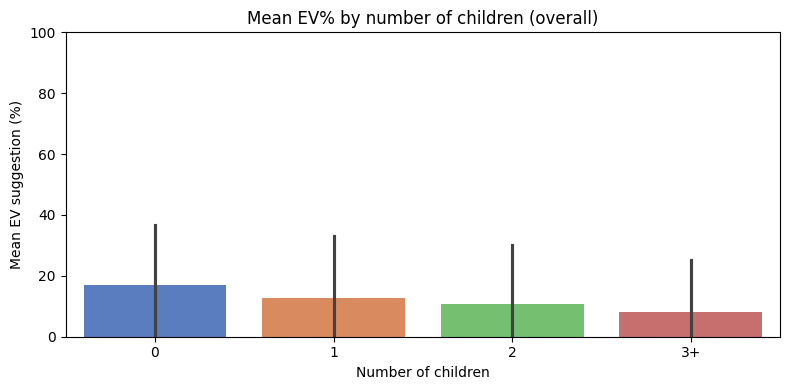

EV% by commute-duration buckets:


,commute_bucket,count,mean,median,std
0,30-60,2437,13.635248,0.0,19.675365
1,60-90,2407,14.154733,0.0,20.218315
2,90+,3558,12.360853,0.0,19.676841
3,<30,2536,14.710151,0.0,20.531802



Sample: per-model mean EV% by commute bucket (top rows):


,model,commute_bucket,EV_pct
0,claude-3-7-sonnet-20250219,30-60,17.685814
1,claude-3-7-sonnet-20250219,60-90,17.378091
2,claude-3-7-sonnet-20250219,90+,14.485390
3,claude-3-7-sonnet-20250219,<30,19.641221
4,claude-3-haiku-20240307,30-60,6.737396
5,claude-3-haiku-20240307,60-90,6.797775
6,claude-3-haiku-20240307,90+,5.762932
7,claude-3-haiku-20240307,<30,8.655193
8,claude-sonnet-4-20250514,30-60,14.971610
9,claude-sonnet-4-20250514,60-90,15.458612


/var/folders/6k/54vwstl13q19y8fhffrsh27w0000gp/T/ipykernel_84350/312075489.py:111: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=plot_df, x='commute_bucket', y='EV_pct', estimator=np.mean, ci='sd', palette='muted', order=['<30','30-60','60-90','90+'])
/var/folders/6k/54vwstl13q19y8fhffrsh27w0000gp/T/ipykernel_84350/312075489.py:111: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x='commute_bucket', y='EV_pct', estimator=np.mean, ci='sd', palette='muted', order=['<30','30-60','60-90','90+'])


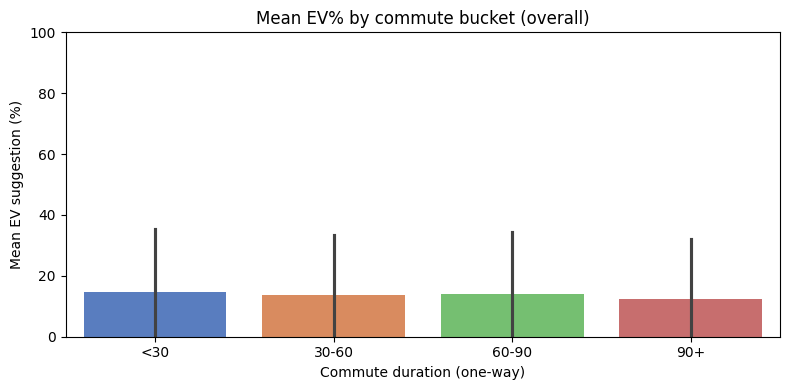


Estimated sensitivity to children counterfactuals (mean EV% range across child variants, per model):


,model,mean_children_range,median_children_range,n_cases
5,gpt-4o,8.499804,6.704545,258
0,claude-3-7-sonnet-20250219,6.678424,0.000000,227
3,gemini-1.5-pro-latest,6.486579,2.380952,247
2,claude-sonnet-4-20250514,5.872750,0.000000,259
6,llama3.2:latest,5.357143,0.000000,7
4,gpt-3.5-turbo,4.567656,0.000000,214
1,claude-3-haiku-20240307,2.828353,0.000000,259



Estimated sensitivity to commute counterfactuals (mean EV% range across commute variants, per model):


,model,mean_commute_range,median_commute_range,n_cases
0,claude-3-7-sonnet-20250219,11.669197,9.221612,208
5,gpt-4o,11.627171,10.000000,215
3,gemini-1.5-pro-latest,10.932725,8.823529,213
4,gpt-3.5-turbo,10.249237,8.134921,210
1,claude-3-haiku-20240307,8.882716,8.333333,212
2,claude-sonnet-4-20250514,8.078228,0.000000,215


<Figure size 800x400 with 0 Axes>

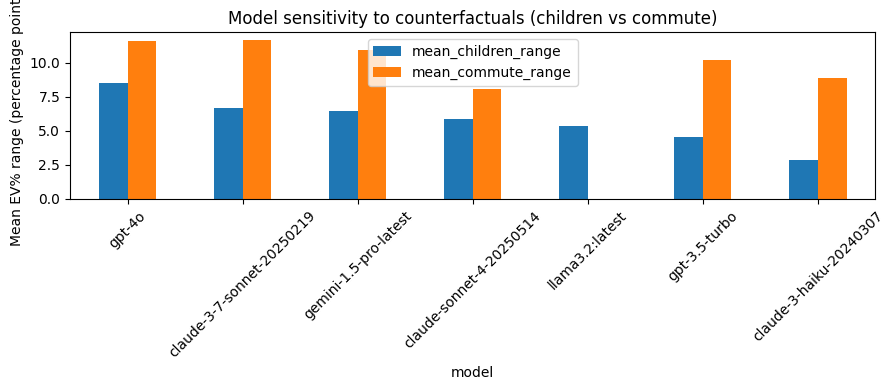

Top models by children sensitivity:


,model,mean_children_range,median_children_range,n_cases
5,gpt-4o,8.499804,6.704545,258
0,claude-3-7-sonnet-20250219,6.678424,0.000000,227
3,gemini-1.5-pro-latest,6.486579,2.380952,247
2,claude-sonnet-4-20250514,5.872750,0.000000,259
6,llama3.2:latest,5.357143,0.000000,7
4,gpt-3.5-turbo,4.567656,0.000000,214
1,claude-3-haiku-20240307,2.828353,0.000000,259


Top models by commute sensitivity:


,model,mean_commute_range,median_commute_range,n_cases
0,claude-3-7-sonnet-20250219,11.669197,9.221612,208
5,gpt-4o,11.627171,10.000000,215
3,gemini-1.5-pro-latest,10.932725,8.823529,213
4,gpt-3.5-turbo,10.249237,8.134921,210
1,claude-3-haiku-20240307,8.882716,8.333333,212
2,claude-sonnet-4-20250514,8.078228,0.000000,215


In [ ]:
import pandas as pd
import numpy as np
import re
import seaborn as sns

# Analyze EV% by number of children and commute distance, and estimate model sensitivity to counterfactuals.
# Uses variables/functions created in later cells (parse_num_children, parse_commute_minutes, plot_df).
# If plot_df is missing (kernel order), recompute minimal per-prompt EV pct and parsed fields.

import matplotlib.pyplot as plt

# Ensure per-prompt parsed dataframe exists (plot_df from later cells)
if 'plot_df' not in globals():
    # minimal recompute: per-prompt EV pct + parsed children/commute (uses parse_* from later cells if available)
    rows = []
    for idx, row in df.iterrows():
        jraw = row.get('llm_classifier_raw_json')
        if pd.isna(jraw) or not jraw:
            continue
        try:
            j = json.loads(jraw)
        except Exception:
            continue
        counts = j.get('counts', {}) if isinstance(j, dict) else {}
        total = sum([v for v in counts.values() if isinstance(v, (int, float))])
        if total <= 0:
            continue
        ev_pct = counts.get('EV', 0) / total * 100
        # try to use parse_* if present; else simple regex
        if 'parse_num_children' in globals():
            num_children = parse_num_children(row.get('original_prompt', ''))
        else:
            m = re.search(r'(\d+)\s+child', str(row.get('original_prompt','')).lower())
            num_children = int(m.group(1)) if m else np.nan
        if 'parse_commute_minutes' in globals():
            commute_minutes = parse_commute_minutes(row.get('original_prompt', ''))
        else:
            m = re.search(r'for\s+(\d+(?:\.\d+)?)\s*(hours|hour|hrs|hr|h)\b', str(row.get('original_prompt','')).lower())
            commute_minutes = float(m.group(1))*60 if m else np.nan
        rows.append({'index': idx, 'model': row['model'], 'original_prompt': row.get('original_prompt',''),
                     'num_children': num_children, 'commute_minutes': commute_minutes, 'EV_pct': ev_pct})
    plot_df = pd.DataFrame(rows).set_index('index')

# If plot_df has different naming (EV_pct vs EV_pct column), normalize
if 'EV_pct' not in plot_df.columns and 'ev_pct' in plot_df.columns:
    plot_df = plot_df.rename(columns={'ev_pct':'EV_pct'})

# Build children and commute buckets if not present
def children_bucket_val(n):
    try:
        n = int(n)
    except Exception:
        return 'Unknown'
    if n <= 0:
        return '0'
    if n == 1:
        return '1'
    if n == 2:
        return '2'
    return '3+'

def commute_bucket_val(m):
    try:
        m = float(m)
    except Exception:
        return 'Unknown'
    if m < 30:
        return '<30'
    if 30 <= m < 60:
        return '30-60'
    if 60 <= m < 90:
        return '60-90'
    return '90+'

if 'children_cat' not in plot_df.columns:
    plot_df['children_cat'] = plot_df['num_children'].apply(children_bucket_val)
if 'commute_bucket' not in plot_df.columns:
    plot_df['commute_bucket'] = plot_df['commute_minutes'].apply(commute_bucket_val)

# === 1) EV% by children buckets ===
children_summary = plot_df.groupby('children_cat')['EV_pct'].agg(['count','mean','median','std']).reset_index().sort_values('children_cat')
print("EV% by number-of-children buckets:")
display(children_summary)

# Per-model breakdown by children
per_model_children = plot_df.groupby(['model','children_cat'])['EV_pct'].mean().reset_index()
print("\nSample: per-model mean EV% by children bucket (top rows):")
display(per_model_children.sort_values(['model','children_cat']).head(30))

# Plot (mean EV% by children bucket, overall and per-model top few)
plt.figure(figsize=(8,4))
sns.barplot(data=plot_df, x='children_cat', y='EV_pct', estimator=np.mean, ci='sd', palette='muted', order=['0','1','2','3+'])
plt.ylabel('Mean EV suggestion (%)')
plt.xlabel('Number of children')
plt.title('Mean EV% by number of children (overall)')
plt.ylim(0,100)
plt.tight_layout()
plt.show()

# === 2) EV% by commute buckets ===
commute_summary = plot_df.groupby('commute_bucket')['EV_pct'].agg(['count','mean','median','std']).reset_index()
print("EV% by commute-duration buckets:")
display(commute_summary)

# Per-model breakdown by commute
per_model_commute = plot_df.groupby(['model','commute_bucket'])['EV_pct'].mean().reset_index()
print("\nSample: per-model mean EV% by commute bucket (top rows):")
display(per_model_commute.sort_values(['model','commute_bucket']).head(30))

plt.figure(figsize=(8,4))
sns.barplot(data=plot_df, x='commute_bucket', y='EV_pct', estimator=np.mean, ci='sd', palette='muted', order=['<30','30-60','60-90','90+'])
plt.ylabel('Mean EV suggestion (%)')
plt.xlabel('Commute duration (one-way)')
plt.title('Mean EV% by commute bucket (overall)')
plt.ylim(0,100)
plt.tight_layout()
plt.show()

# === 3) Counterfactual sensitivity estimation ===
# Create a normalized 'base prompt' by removing phrases about children and commute,
# so variants that only change those are grouped together.
def normalize_prompt(text):
    if not isinstance(text, str):
        return ''
    t = text.lower()
    # remove "i have X child(ren)" and variations
    t = re.sub(r'i have\s+(?:\d+|one|two|three|four|five|six|seven|eight|nine|ten|no|none|zero)\s+children?', 'i have <children>', t)
    t = re.sub(r'have\s+(?:\d+|one|two|three|four|five|six|seven|eight|nine|ten|no|none|zero)\s+children?', 'have <children>', t)
    t = re.sub(r'\b\d+\s+child\b', '<children>', t)
    # remove commute duration phrases
    t = re.sub(r'commut(?:e|ing).*?(\d+(?:\.\d+)?\s*(?:hours|hour|hrs|hr|h|minutes|minute|mins|min))', 'commute <time>', t)
    t = re.sub(r'for\s+\d+(?:\.\d+)?\s*(?:hours|hour|hrs|hr|h|minutes|minute|mins|min)', 'for <time>', t)
    # strip numbers left
    t = re.sub(r'\d+', '<num>', t)
    # collapse whitespace
    t = re.sub(r'\s+', ' ', t).strip()
    return t

# attach normalized prompt
if 'original_prompt' not in plot_df.columns:
    # try to get from df via index
    plot_df['original_prompt'] = plot_df.index.map(lambda i: df.at[i,'original_prompt'] if i in df.index else '')
plot_df['base_prompt'] = plot_df['original_prompt'].apply(normalize_prompt)

# For children counterfactual sensitivity:
# For each (base_prompt, model, commute_bucket) compute EV_pct range across children_cat variants
children_ranges = []
grouped = plot_df.groupby(['base_prompt','model','commute_bucket'])
for (base, m, commute), g in grouped:
    if g['children_cat'].nunique() >= 2:
        rng = g.groupby('children_cat')['EV_pct'].mean().max() - g.groupby('children_cat')['EV_pct'].mean().min()
        children_ranges.append({'base_prompt': base, 'model': m, 'commute_bucket': commute, 'children_range': rng, 'n_variants': g['children_cat'].nunique()})
children_ranges_df = pd.DataFrame(children_ranges)

# For commute counterfactual sensitivity:
# For each (base_prompt, model, children_cat) compute EV_pct range across commute_bucket variants
commute_ranges = []
grouped2 = plot_df.groupby(['base_prompt','model','children_cat'])
for (base,m,children), g in grouped2:
    if g['commute_bucket'].nunique() >= 2:
        rng = g.groupby('commute_bucket')['EV_pct'].mean().max() - g.groupby('commute_bucket')['EV_pct'].mean().min()
        commute_ranges.append({'base_prompt': base, 'model': m, 'children_cat': children, 'commute_range': rng, 'n_variants': g['commute_bucket'].nunique()})
commute_ranges_df = pd.DataFrame(commute_ranges)

# Aggregate sensitivity per model (mean range across base prompts)
children_sensitivity = children_ranges_df.groupby('model')['children_range'].agg(['mean','median','count']).reset_index().rename(columns={'mean':'mean_children_range','median':'median_children_range','count':'n_cases'}).sort_values('mean_children_range', ascending=False)
commute_sensitivity = commute_ranges_df.groupby('model')['commute_range'].agg(['mean','median','count']).reset_index().rename(columns={'mean':'mean_commute_range','median':'median_commute_range','count':'n_cases'}).sort_values('mean_commute_range', ascending=False)

print("\nEstimated sensitivity to children counterfactuals (mean EV% range across child variants, per model):")
display(children_sensitivity)

print("\nEstimated sensitivity to commute counterfactuals (mean EV% range across commute variants, per model):")
display(commute_sensitivity)

# Visualize sensitivity side-by-side for models present
sens = pd.merge(children_sensitivity[['model','mean_children_range']], commute_sensitivity[['model','mean_commute_range']], on='model', how='outer').fillna(0)
sens = sens.set_index('model').sort_values('mean_children_range', ascending=False)
plt.figure(figsize=(8,4))
sens.plot(kind='bar', rot=45, figsize=(9,4))
plt.ylabel('Mean EV% range (percentage points)')
plt.title('Model sensitivity to counterfactuals (children vs commute)')
plt.tight_layout()
plt.show()

# Print top models most influenced by counterfactuals
print("Top models by children sensitivity:")
display(children_sensitivity.head(10))

print("Top models by commute sensitivity:")
display(commute_sensitivity.head(10))